# Extended-abstract figures &mdash; PLVAE evaluation suite

This notebook produces every figure and number cited in the extended abstract,
organised by the four metric-suite tools the abstract names. **All
visualisation indices, sample-set sizes, and artifact identifiers are defined
once in the config cell** &mdash; a single edit propagates through every panel.

## Pipeline (executed once in *Setup*)

1. Load problem + train/val/test designs.
2. Load the *performance-constrained* PLVAE (encoder, decoder, predictor).
3. Load the *reconstruction-only* LVAE (same seed, `perf_threshold=1000.0`) for the dual gap.
4. Load CGAN-CNN-2D and Diffusion-2D-cond generators; sample `N_GEN_SAMPLES` from each at matched conditions.
5. Encode every population through both LVAEs and pre-compute residual + dual-gap arrays.

## Sections (each one is a stand-alone evaluation tool)

| # | Section | Abstract claim |
|---|---|---|
| 1 | **LV-MMD** &mdash; latent distributional similarity | "primary metric&hellip; covers the right structural modes" |
| 2 | **Projection Residual** &mdash; per-sample manifold distance | "per-sample quality signal&hellip; surfaces differences between generators" |
| 3 | **Dual-LVAE Gap** &mdash; perf-relevant vs cosmetic noise | "distinguish cosmetic noise from performance-relevant deviations" |
| 4 | **LV-Projection** &mdash; encode&ndash;decode as repair | "feasibility repair operator to improve generated designs" |
| A | Validation: rank-recovery vs ground-truth COG/IOG | "LV-based rankings track ground-truth COG orderings" |
| B | Validation: on vs off-manifold detection / diversity | "projection property&hellip; cleaned-up on-manifold version" |
| 5 | God-figure summary panel | Figure&nbsp;1 of the extended abstract |

Every per-sample visualisation reads its index from the central
`HIGHLIGHT_IDX` / `VIZ_INDICES` constants in section&nbsp;0 &mdash; change those
values to swap displayed samples without touching plotting code.


In [1]:
"""Imports and matplotlib defaults (run once)."""
from __future__ import annotations

import math
import os
import time

from engibench.utils.all_problems import BUILTIN_PROBLEMS
from engiopt.vanilla_lvae.components import SNMLPPredictor
import matplotlib as mpl
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import QuantileTransformer
from sklearn.preprocessing import RobustScaler
import torch as th

from engiopt import metrics
from engiopt.dataset_sample_conditions import sample_conditions
from engiopt.transforms import get_performance_target
from engiopt.transforms import get_scalar_condition_keys
import wandb

# Vector-editable output: text stays as text in SVG/PDF.
mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams.update(
    {
        "font.size": 16,
        "axes.titlesize": 20,
        "axes.labelsize": 18,
        "xtick.labelsize": 15,
        "ytick.labelsize": 15,
        "legend.fontsize": 15,
        "legend.title_fontsize": 16,
        "figure.titlesize": 22,
    }
)

if th.backends.mps.is_available():
    device = th.device("mps")
elif th.cuda.is_available():
    device = th.device("cuda")
else:
    device = th.device("cpu")
print(f"device = {device}")

/opt/anaconda3/envs/EngiBench312/lib/python3.12/site-packages/gymnasium/spaces/box.py:235: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/opt/anaconda3/envs/EngiBench312/lib/python3.12/site-packages/gymnasium/spaces/box.py:305: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


device = mps


In [2]:
# =====================================================================
# CONFIG  --  every constant the rest of the notebook reads.
#
# Edit any value here and rerun all cells below to swap problem,
# generator seed, or visualised samples.
# =====================================================================

# ----- Problem / WandB project --------------------------------------------------
PROBLEM_ID = "heatconduction2d"
WANDB_ENTITY: str | None = "engibench"
WANDB_PROJECT = "engiopt"

# ----- Performance-constrained PLVAE -------------------------------------------
# Resolved entirely from (seed, rec_threshold, perf_threshold) via the alias
# `seed_{seed}_rec{rec}_perf{perf}` in load_lvae_encoder_decoder(). Swapping
# PROBLEM_ID picks up that problem's matching artifact automatically -- no
# run/sweep ID pinning required.
PLVAE_SEED = 1
PLVAE_REC_THRESH = 0.015
PLVAE_PERF_THRESH = 0.01

# ----- Reconstruction-only LVAE (used by the dual-gap metric) ------------------
# Same seed as the PLVAE; perf_threshold=1000.0 is the recon-only sentinel.
RECON_LVAE_PROJECT = WANDB_PROJECT
RECON_LVAE_REC_THRESH = 0.015
RECON_LVAE_PERF_THRESH = 1000.0

# ----- Generators (sampled at matched conditions) ------------------------------
CGAN_SEED = 1
DIFF_SEED = 1
N_GEN_SAMPLES = 50  # per generator
N_COMMON = 50  # matched-N for every distributional comparison
SIGMA_REF_N = 200  # train designs used to fix kernel bandwidth

# ----- Visualisation indices  (CHANGE THESE TO SWAP SAMPLES) --------------------
# HIGHLIGHT_IDX drives every single-sample triptych / star marker / re-optimise
# trajectory.  VIZ_INDICES drives every multi-panel strip.
HIGHLIGHT_IDX: int = 0
VIZ_INDICES: list[int] = [0, 7, 13, 22, 41]  # length determines strip width

# Set to True to drive HIGHLIGHT_IDX from "max projection residual" instead of
# the literal index above.  Useful when prospecting for the most off-manifold
# CGAN sample.
HIGHLIGHT_BY_MAX_RESIDUAL = False

# ----- Section A (cheap-metric vs COG/IOG ranking) ----------------------------
# Section A pulls eval/* summaries directly from WandB for the problems and
# seed range defined inside cell 28 (PROBLEMS_TO_ANALYSE, SEEDS_TO_ANALYSE),
# then caches them to ./wandb_eval_metrics_cache.json next to the notebook.

# ----- Plumbing ----------------------------------------------------------------
CHUNK = 512  # batch size for chunked encode/decode
FIG_OUT = "../../paper/figures/extended_abstract_god_figure.pdf"
FIG_DIR = os.path.dirname(FIG_OUT)
os.makedirs(FIG_DIR, exist_ok=True)


def artifact_path(name: str, alias: str, project: str = WANDB_PROJECT) -> str:
    """Build a WandB artifact path honouring the optional entity."""
    prefix = f"{WANDB_ENTITY}/{project}" if WANDB_ENTITY else project
    return f"{prefix}/{name}:{alias}"


def run_path(run_id: str, project: str = WANDB_PROJECT) -> str:
    prefix = f"{WANDB_ENTITY}/{project}" if WANDB_ENTITY else project
    return f"{prefix}/{run_id}"


def save_vec(fig: plt.Figure, stem: str, *, dpi: int = 300) -> str:
    """Save fig as .pdf/.svg/.png to FIG_DIR/<stem>.{pdf,svg,png}."""
    base = os.path.join(FIG_DIR, stem)
    fig.savefig(f"{base}.pdf", bbox_inches="tight")
    fig.savefig(f"{base}.svg", bbox_inches="tight")
    fig.savefig(f"{base}.png", bbox_inches="tight", dpi=dpi)
    print(f"saved: {base}.{{pdf,svg,png}}")
    return base


np.random.seed(0)
th.manual_seed(0)
api = wandb.Api()
print(f"problem={PROBLEM_ID} | PLVAE seed={PLVAE_SEED} rec={PLVAE_REC_THRESH} perf={PLVAE_PERF_THRESH}")
print(f"recon LVAE rec={RECON_LVAE_REC_THRESH} perf={RECON_LVAE_PERF_THRESH}")
print(f"HIGHLIGHT_IDX={HIGHLIGHT_IDX}  VIZ_INDICES={VIZ_INDICES}  N_GEN_SAMPLES={N_GEN_SAMPLES}  N_COMMON={N_COMMON}")

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /Users/mkeeler/.netrc.


problem=heatconduction2d | PLVAE seed=1 rec=0.015 perf=0.01
recon LVAE rec=0.015 perf=1000.0
HIGHLIGHT_IDX=0  VIZ_INDICES=[0, 7, 13, 22, 41]  N_GEN_SAMPLES=50  N_COMMON=50


## Setup &mdash; load every model and dataset once

The cells below run sequentially; every downstream section assumes the names
they introduce are in scope. Outputs after these cells are deterministic given
the config block above.


In [3]:
# --- Load problem + extract metadata -----------------------------------------
problem = BUILTIN_PROBLEMS[PROBLEM_ID]()
problem.reset(seed=0)

design_shape = problem.design_space.shape  # e.g. (101, 101)
H, W = design_shape
scalar_cond_keys = get_scalar_condition_keys(problem, problem.dataset["train"])
obj_keys = [name for name, _ in problem.objectives]
n_perf = len(obj_keys)
print(f"problem={PROBLEM_ID} | design_shape={design_shape} | conds={scalar_cond_keys} | objs={obj_keys}")

problem=heatconduction2d | design_shape=(101, 101) | conds=['volume', 'length'] | objs=['c']


In [4]:
# --- Load performance-constrained PLVAE via threshold-based alias ------------
# Uses load_lvae_encoder_decoder(), which resolves the artifact alias
# `seed_{seed}_rec{rec}_perf{perf}` -- the same mechanism used for the
# reconstruction-only LVAE below.  Swap PROBLEM_ID + thresholds in the config
# block above to point at any problem's PLVAE; no run/sweep IDs needed.
from engiopt.vanilla_lvae.utils import load_lvae_encoder_decoder
from engiopt.vanilla_lvae.utils import PrunedEncoder

encoder_perf, decoder_perf, perf_cfg = load_lvae_encoder_decoder(
    problem_id=PROBLEM_ID,
    seed=PLVAE_SEED,
    rec_threshold=PLVAE_REC_THRESH,
    perf_threshold=PLVAE_PERF_THRESH,
    wandb_project=WANDB_PROJECT,
    wandb_entity=WANDB_ENTITY,
    device=device,
    design_shape=design_shape,
)
encoder_perf.eval().to(device)
decoder_perf.eval()

# Also expose the raw run.config dict (`cfg`) and torch checkpoint (`ckpt`) so
# downstream cells that build extra components from the same artifact -- e.g.
# the SNMLPPredictor head in the predicted-vs-simulated cell -- pick up the
# currently-configured PROBLEM_ID + thresholds instead of stale Jupyter state.
# wandb caches the download locally so this does not re-fetch.
_plvae_alias = f"seed_{PLVAE_SEED}_rec{PLVAE_REC_THRESH}_perf{PLVAE_PERF_THRESH}"
_plvae_artifact = api.artifact(
    artifact_path(f"{PROBLEM_ID}_constrained_vanilla_plvae_2d", _plvae_alias),
    type="model",
)
_plvae_run = _plvae_artifact.logged_by()
cfg = dict(_plvae_run.config)
ckpt = th.load(
    os.path.join(_plvae_artifact.download(), "constrained_vanilla_plvae.pth"),
    map_location="cpu",
    weights_only=False,
)

latent_dim = perf_cfg.latent_dim
resize_dimensions = perf_cfg.resize_dimensions
whitening = perf_cfg.whitening
decoder_lipschitz_scale = perf_cfg.decoder_lipschitz_scale
perf_dim = perf_cfg.perf_dim

if isinstance(encoder_perf, PrunedEncoder):
    active_mask = (~encoder_perf._p.cpu()).numpy()
    active_dims = np.nonzero(active_mask)[0]
else:
    active_mask = np.ones(latent_dim, dtype=bool)
    active_dims = np.arange(latent_dim)
print(f"PLVAE: latent_dim={latent_dim}  active={len(active_dims)}  pruned={latent_dim - len(active_dims)}")
print(f"       run='{_plvae_run.name}'  seed={cfg.get('seed')}  cond_predictor={cfg.get('conditional_predictor')}")

wandb: Downloading large artifact 'heatconduction2d_constrained_vanilla_plvae_2d:seed_1_rec0.015_perf0.01', 95.48MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:00.6 (148.5MB/s)
wandb: Downloading large artifact 'heatconduction2d_constrained_vanilla_plvae_2d:seed_1_rec0.015_perf0.01', 95.48MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:00.3 (272.9MB/s)


PLVAE: latent_dim=100  active=9  pruned=91
       run='heatconduction2d__constrained_vanilla_plvae_2d__1__1776690481'  seed=1  cond_predictor=True


In [5]:
# --- Load reconstruction-only LVAE (perf_threshold=1000.0) for the dual gap ---
# Same WandB seed as the PLVAE.  Uses load_lvae_encoder_decoder() which
# resolves the artifact alias `seed_{seed}_rec{r}_perf{p}`.
from engiopt.vanilla_lvae.utils import load_lvae_encoder_decoder

encoder_recon, decoder_recon, recon_cfg = load_lvae_encoder_decoder(
    problem_id=PROBLEM_ID,
    seed=PLVAE_SEED,
    rec_threshold=RECON_LVAE_REC_THRESH,
    perf_threshold=RECON_LVAE_PERF_THRESH,
    wandb_project=RECON_LVAE_PROJECT,
    wandb_entity=WANDB_ENTITY,
    device=device,
    design_shape=design_shape,
)
encoder_recon.eval().to(device)
decoder_recon.eval()

# Report the recon-LVAE's active-dim count and compare to the PLVAE.  A
# mismatch usually means the chosen thresholds resolved to a different
# capacity than the PLVAE -- adjust RECON_LVAE_REC_THRESH if a match matters.
from engiopt.vanilla_lvae.utils import PrunedEncoder

if isinstance(encoder_recon, PrunedEncoder):
    recon_active = int((~encoder_recon._p.cpu()).sum())
else:
    recon_active = recon_cfg.latent_dim
plvae_active = len(active_dims)
print(
    f"recon-only LVAE: latent_dim={recon_cfg.latent_dim}  active={recon_active}  rec/perf={RECON_LVAE_REC_THRESH}/{RECON_LVAE_PERF_THRESH}"
)
print(
    f"                 PLVAE active={plvae_active}  ->  "
    + ("MATCH" if recon_active == plvae_active else f"WARNING: differs from PLVAE by {recon_active - plvae_active}")
)

wandb: Downloading large artifact 'heatconduction2d_constrained_vanilla_plvae_2d:seed_1_rec0.015_perf1000.0', 95.02MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:00.4 (211.5MB/s)


recon-only LVAE: latent_dim=100  active=8  rec/perf=0.015/1000.0
                 PLVAE active=9  ->  WARNING: differs from PLVAE by -1


In [6]:
# --- Train / val / test splits + performance targets ------------------------
train_ds = problem.dataset["train"].with_format("torch")
val_ds = problem.dataset["val"].with_format("torch")
test_ds = problem.dataset["test"].with_format("torch")

x_train = train_ds["optimal_design"][:].unsqueeze(1).float()
x_val = val_ds["optimal_design"][:].unsqueeze(1).float()
x_test_full = test_ds["optimal_design"][:].unsqueeze(1).float()

p_train = get_performance_target(problem, train_ds)
p_val = get_performance_target(problem, val_ds)
p_test_full = get_performance_target(problem, test_ds)

print(f"x_train={tuple(x_train.shape)}  x_val={tuple(x_val.shape)}  x_test={tuple(x_test_full.shape)}")

x_train=(361, 1, 101, 101)  x_val=(40, 1, 101, 101)  x_test=(40, 1, 101, 101)


In [7]:
# --- Load CGAN-CNN-2D generator + sample at controlled conditions ------------
from engiopt.cgan_cnn_2d.cgan_cnn_2d import Generator as CGANGenerator

cgan_artifact = api.artifact(artifact_path(f"{PROBLEM_ID}_cgan_cnn_2d_generator", f"seed_{CGAN_SEED}"), type="model")
cgan_run = cgan_artifact.logged_by()
cgan_ckpt = th.load(os.path.join(cgan_artifact.download(), "generator.pth"), map_location=device)

cgan = CGANGenerator(
    latent_dim=cgan_run.config["latent_dim"],
    n_conds=len(scalar_cond_keys),
    design_shape=design_shape,
)
cgan.load_state_dict(cgan_ckpt["generator"])
cgan.eval().to(device)

# Matched conditions = test-set indices, used by both CGAN and Diffusion.
cond_tensor, sampled_conds, target_designs_np, test_idx = sample_conditions(
    problem,
    N_GEN_SAMPLES,
    device,
    seed=CGAN_SEED,
)
x_test_targets = th.from_numpy(target_designs_np).unsqueeze(1).float()  # (N, 1, H, W)
p_test_targets = p_test_full[test_idx].numpy()  # (N, n_perf)

with th.no_grad():
    z_noise = th.randn((N_GEN_SAMPLES, cgan_run.config["latent_dim"], 1, 1), device=device)
    x_cgan = cgan(z_noise, cond_tensor.unsqueeze(-1).unsqueeze(-1)).detach().cpu().clamp(0, 1)
print(f"x_cgan = {tuple(x_cgan.shape)}  range=[{x_cgan.min():.3f}, {x_cgan.max():.3f}]")

wandb:   1 of 1 files downloaded.  


x_cgan = (50, 1, 101, 101)  range=[0.000, 1.000]


/opt/anaconda3/envs/EngiBench312/lib/python3.12/site-packages/torch/nn/functional.py:4678: UserWarning: The operator 'aten::_upsample_bilinear2d_aa.out' is not currently supported on the MPS backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/mps/MPSFallback.mm:14.)
  return torch._C._nn._upsample_bilinear2d_aa(


In [8]:
# --- Load Diffusion-2D-cond generator + sample at the SAME conditions --------
from diffusers import UNet2DConditionModel
from engiopt.diffusion_2d_cond.diffusion_2d_cond import beta_schedule
from engiopt.diffusion_2d_cond.diffusion_2d_cond import DiffusionSampler

diff_artifact = api.artifact(artifact_path(f"{PROBLEM_ID}_diffusion_2d_cond_model", f"seed_{DIFF_SEED}"), type="model")
diff_run = diff_artifact.logged_by()
diff_ckpt = th.load(os.path.join(diff_artifact.download(), "model.pth"), map_location=device)

unet = UNet2DConditionModel(
    sample_size=design_shape,
    in_channels=1,
    out_channels=1,
    cross_attention_dim=64,
    block_out_channels=(32, 64, 128, 256),
    down_block_types=("CrossAttnDownBlock2D", "CrossAttnDownBlock2D", "CrossAttnDownBlock2D", "DownBlock2D"),
    up_block_types=("UpBlock2D", "CrossAttnUpBlock2D", "CrossAttnUpBlock2D", "CrossAttnUpBlock2D"),
    layers_per_block=diff_run.config["layers_per_block"],
    transformer_layers_per_block=1,
    encoder_hid_dim=len(scalar_cond_keys),
    only_cross_attention=True,
).to(device)
unet.load_state_dict(diff_ckpt["model"])
unet.eval()

opts = {
    "cosine": diff_run.config["noise_schedule"] == "cosine",
    "exp_biasing": diff_run.config["noise_schedule"] == "exp",
    "exp_bias_factor": 1,
}
betas = beta_schedule(t=diff_run.config["num_timesteps"], start=1e-4, end=0.02, scale=1.0, options=opts)
sampler = DiffusionSampler(diff_run.config["num_timesteps"], betas)

with th.no_grad():
    x_t = th.randn((N_GEN_SAMPLES, 1, *design_shape), device=device)
    for i in reversed(range(diff_run.config["num_timesteps"])):
        t = th.full((N_GEN_SAMPLES,), i, device=device, dtype=th.long)
        x_t = sampler.sample_timestep(unet, x_t, t, cond_tensor.unsqueeze(1))
    x_diff = x_t.detach().cpu().clamp(0, 1)
print(f"x_diff = {tuple(x_diff.shape)}  range=[{x_diff.min():.3f}, {x_diff.max():.3f}]")

wandb: Downloading large artifact 'heatconduction2d_diffusion_2d_cond_model:seed_1', 200.90MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:00.5 (422.3MB/s)


x_diff = (50, 1, 101, 101)  range=[0.000, 0.822]


In [9]:
# --- One-shot encode/decode through BOTH LVAEs for every population ----------
# Centralising this here means every downstream section reads pre-computed
# numpy arrays.  Avoids re-encoding the same designs in five places.


def _chunked_encode(enc: nn.Module, x_th: th.Tensor) -> np.ndarray:
    with th.no_grad():
        z = th.cat([enc(x_th[i : i + CHUNK].to(device)) for i in range(0, len(x_th), CHUNK)], dim=0)
    return z.cpu().numpy()


def _chunked_decode(dec: nn.Module, z_np: np.ndarray) -> np.ndarray:
    with th.no_grad():
        x = th.cat(
            [dec(th.from_numpy(z_np[i : i + CHUNK]).float()).clamp(0, 1) for i in range(0, len(z_np), CHUNK)],
            dim=0,
        )
    return x.numpy()


def _encode_decode_pair(x_th: th.Tensor) -> dict[str, np.ndarray]:
    """Encode through both LVAEs, decode each, and return all six arrays."""
    z_perf = _chunked_encode(encoder_perf, x_th)
    z_recon = _chunked_encode(encoder_recon, x_th)
    proj_perf = _chunked_decode(decoder_perf, z_perf)  # (N, 1, H, W)
    proj_recon = _chunked_decode(decoder_recon, z_recon)
    return {
        "z_perf": z_perf,
        "z_recon": z_recon,
        "proj_perf": proj_perf.squeeze(1) if proj_perf.ndim == 4 else proj_perf,
        "proj_recon": proj_recon.squeeze(1) if proj_recon.ndim == 4 else proj_recon,
    }


print("encoding train / val / test / CGAN / Diffusion / test-targets ...")
enc_train = _encode_decode_pair(x_train)
enc_val = _encode_decode_pair(x_val)
enc_test = _encode_decode_pair(x_test_full)
enc_cgan = _encode_decode_pair(x_cgan)
enc_diff = _encode_decode_pair(x_diff)
enc_targets = _encode_decode_pair(x_test_targets)
print("done.")

encoding train / val / test / CGAN / Diffusion / test-targets ...
done.


In [10]:
# --- Pre-compute residual + dual-gap arrays for every population -------------
# residual_perf  = ||x - decode_perf(encode_perf(x))||                  (per-sample MSE)
# residual_recon = ||x - decode_recon(encode_recon(x))||
# dual_gap       = ||decode_perf(encode_perf(x)) - decode_recon(encode_recon(x))||
#
# All three numbers are produced at once and stored on each `enc_*` dict.


def _per_sample_mse(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    return ((a - b) ** 2).reshape(len(a), -1).mean(axis=1)


def _per_sample_l2(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    return np.linalg.norm((a - b).reshape(len(a), -1), axis=1)


def _attach_diagnostics(enc: dict, x_th: th.Tensor) -> None:
    x_np = x_th.numpy().squeeze(1) if x_th.ndim == 4 else x_th.numpy()
    enc["x"] = x_np
    enc["residual_perf"] = _per_sample_mse(x_np, enc["proj_perf"])
    enc["residual_recon"] = _per_sample_mse(x_np, enc["proj_recon"])
    enc["dual_gap"] = _per_sample_mse(enc["proj_perf"], enc["proj_recon"])
    # Pixel-space L2 residual (used in the abstract's "projection residual" plots).
    enc["proj_res_l2"] = _per_sample_l2(x_np, enc["proj_perf"])


for name, enc, x in [
    ("train", enc_train, x_train),
    ("val", enc_val, x_val),
    ("test", enc_test, x_test_full),
    ("cgan", enc_cgan, x_cgan),
    ("diff", enc_diff, x_diff),
    ("targets", enc_targets, x_test_targets),
]:
    _attach_diagnostics(enc, x)

print(
    f"{'set':10s}  {'n':>5s}  {'res_perf (MSE)':>16s}  {'res_recon (MSE)':>17s}  {'dual_gap (MSE)':>16s}  {'res_perf (L2)':>14s}"
)
for name, enc in [
    ("train", enc_train),
    ("val", enc_val),
    ("test", enc_test),
    ("cgan", enc_cgan),
    ("diff", enc_diff),
    ("targets", enc_targets),
]:
    print(
        f"{name:10s}  {len(enc['x']):>5d}  "
        f"{np.median(enc['residual_perf']):>16.6f}  "
        f"{np.median(enc['residual_recon']):>17.6f}  "
        f"{np.median(enc['dual_gap']):>16.6f}  "
        f"{np.median(enc['proj_res_l2']):>14.3f}"
    )

# Resolve HIGHLIGHT_IDX now that residuals exist.
if HIGHLIGHT_BY_MAX_RESIDUAL:
    HIGHLIGHT_IDX = int(np.argmax(enc_cgan["proj_res_l2"]))
    print(f"\nHIGHLIGHT_BY_MAX_RESIDUAL=True  ->  HIGHLIGHT_IDX={HIGHLIGHT_IDX}")
print(f"HIGHLIGHT_IDX = {HIGHLIGHT_IDX}")

set             n    res_perf (MSE)    res_recon (MSE)    dual_gap (MSE)   res_perf (L2)
train         361          0.002038           0.001794          0.002437           4.560
val            40          0.034794           0.036716          0.015630          18.831
test           40          0.028237           0.028735          0.015557          16.972
cgan           50          0.128491           0.111232          0.066562          36.204
diff           50          0.132568           0.120206          0.122532          36.774
targets        50          0.026616           0.027154          0.015299          16.471
HIGHLIGHT_IDX = 0


In [11]:
# --- Top-2 active-dim ordering + dataset latent cloud (used by every scatter)
z_train_active = enc_train["z_perf"][:, active_dims]
z_val_active = enc_val["z_perf"][:, active_dims]
z_test_active = enc_test["z_perf"][:, active_dims]

z_std = enc_train["z_perf"].std(axis=0)
order = np.argsort(z_std)[::-1]
d0, d1 = int(order[0]), int(order[1])
print(f"top-2 active dims: d0={d0}  d1={d1}  (std={z_std[d0]:.3f}, {z_std[d1]:.3f})")

# Cached dataset cloud + colour-norm reused by every latent scatter below.
z_dataset = np.concatenate([enc_train["z_perf"], enc_val["z_perf"]], axis=0)
p_dataset = np.concatenate([p_train.numpy()[:, 0], p_val.numpy()[:, 0]], axis=0)
P_BOUND = np.unique(np.percentile(p_dataset, np.linspace(0, 100, 256)))
P_NORM = mcolors.BoundaryNorm(P_BOUND, ncolors=256)


def latent_scatter_dataset(ax, *, s: int = 24, alpha: float = 0.45, label: str = "dataset"):
    """Draw the dataset cloud on `ax` with the canonical colour scheme."""
    return ax.scatter(
        z_dataset[:, d0],
        z_dataset[:, d1],
        c=p_dataset,
        cmap="viridis",
        norm=P_NORM,
        s=s,
        alpha=alpha,
        edgecolors="none",
        label=label,
    )


def colourbar(ax, sc):
    cbar = ax.figure.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(obj_keys[0], fontsize=14)
    sci = ScalarFormatter(useMathText=True)
    sci.set_scientific(True)
    sci.set_powerlimits((0, 0))
    cbar.formatter = sci
    cbar.update_ticks()
    cbar.ax.tick_params(labelsize=12)
    return cbar

top-2 active dims: d0=99  d1=98  (std=16.652, 9.458)


## Contribution&nbsp;1 &mdash; LV-MMD

The primary metric of the paper. Encodes a candidate generator and a reference
into the PLVAE's pruned latent space and reports MMD with a Gaussian kernel.

Because the encoder has stripped surface noise, LV-MMD measures whether the
generator covers the right *structural modes* of the design space rather than
matching pixel-level details.

The two figures below establish the metric's calibration:
- **Bar chart** &mdash; pixel-MMD vs LV-MMD at matched-N for real generators *and* a garbage baseline; a self-MMD floor is shown so the meaningful signal is the *excess*.
- **Bandwidth sweep** &mdash; LV-MMD as &sigma; varies; the median heuristic sometimes hides a collapsed cluster, and the sweep shows the regime where the signal recovers.


In [12]:
# --- Garbage battery (NOISE + PHYSICAL classes), used by sections 1, 2, 3, B
# Each class produces N_COMMON jittered replicates so every distributional
# comparison runs at matched n.
rng = np.random.default_rng(0)
x_real_ref = enc_train["x"][0].copy()
target_vf = float(x_real_ref.mean())

NOISE_TYPES = [
    "uniform noise",
    "gaussian noise",
    f"random binary @ vf={target_vf:.2f}",
    "checkerboard noise",
    "shuffled real",
]
PHYS_TYPES = ["all zeros", "all ones", f"uniform gray = {target_vf:.2f}", "inverted real", "center blob"]

yy, xx = np.mgrid[0:H, 0:W].astype(np.float32)
PHYS_BASE = [
    np.zeros((H, W), dtype=np.float32),
    np.ones((H, W), dtype=np.float32),
    np.full((H, W), target_vf, dtype=np.float32),
    (1.0 - x_real_ref).astype(np.float32),
    np.exp(-((xx - W / 2) ** 2 + (yy - H / 2) ** 2) / (2 * (H / 6) ** 2)).astype(np.float32),
]


def _build_noise(seed: int) -> np.ndarray:
    g = np.random.default_rng(seed)
    return np.stack(
        [
            g.uniform(0, 1, size=(H, W)).astype(np.float32),
            np.clip(g.normal(0.5, 0.3, size=(H, W)), 0, 1).astype(np.float32),
            (g.random((H, W)) < target_vf).astype(np.float32),
            ((np.indices((H, W)).sum(axis=0) + g.integers(0, 2)) % 2).astype(np.float32),
            g.permutation(x_real_ref.flatten()).reshape(H, W).astype(np.float32),
        ]
    )


def _build_phys(seed: int, jitter: float = 0.02) -> np.ndarray:
    g = np.random.default_rng(seed)
    return np.stack([np.clip(b + g.normal(0, jitter, size=(H, W)).astype(np.float32), 0, 1) for b in PHYS_BASE])


# Pool of N_COMMON replicates per class.
N_PER = max(N_COMMON, 50)
x_noise_pool = np.concatenate([_build_noise(1000 + s) for s in range(N_PER)], axis=0)[:, None]
x_phys_pool = np.concatenate([_build_phys(2000 + s) for s in range(N_PER)], axis=0)[:, None]
print(f"garbage pools: noise n={len(x_noise_pool)}  physical n={len(x_phys_pool)}")

enc_noise = _encode_decode_pair(th.from_numpy(x_noise_pool).float())
enc_phys = _encode_decode_pair(th.from_numpy(x_phys_pool).float())
_attach_diagnostics(enc_noise, th.from_numpy(x_noise_pool).float())
_attach_diagnostics(enc_phys, th.from_numpy(x_phys_pool).float())

garbage pools: noise n=250  physical n=250


/opt/anaconda3/envs/EngiBench312/lib/python3.12/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/opt/anaconda3/envs/EngiBench312/lib/python3.12/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/opt/anaconda3/envs/EngiBench312/lib/python3.12/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/opt/anaconda3/envs/EngiBench312/lib/python3.12/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/opt/anaconda3/envs/EngiBench312/lib/python3.12/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/opt/anaconda3/envs/EngiBench312/lib/python3.12/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: invalid value encountered in matmul
  Q, 

FIXED bandwidths (median heuristic, n=200):
  sigma_pixel  = 31.5238   (D = 10201)
  sigma_pca    = 21.9594   (D = 9)
  sigma_latent = 18.5311   (D = 9)
  [_subsample] pool=40 < n=50; sampling with replacement.
  [_subsample] pool=40 < n=50; sampling with replacement.

ALL MMDs:  n_candidate = n_reference = N_COMMON = 50
set                              pixel-MMD^2     PCA-MMD^2      LV-MMD^2
----------------------------------------------------------------------------
self (train/2 vs train/2)             0.0230        0.0198        0.0132
test (real holdout)                   0.0556        0.0747        0.1183
CGAN                                  0.4187        0.1728        0.3170
Diffusion                             0.5032        0.6613        0.3455
Garbage: noise                        0.1518        0.2763        0.3919
Garbage: physical                     0.3264        0.3188        0.2438
saved: ../../paper/figures/mmd_bars.{pdf,svg,png}


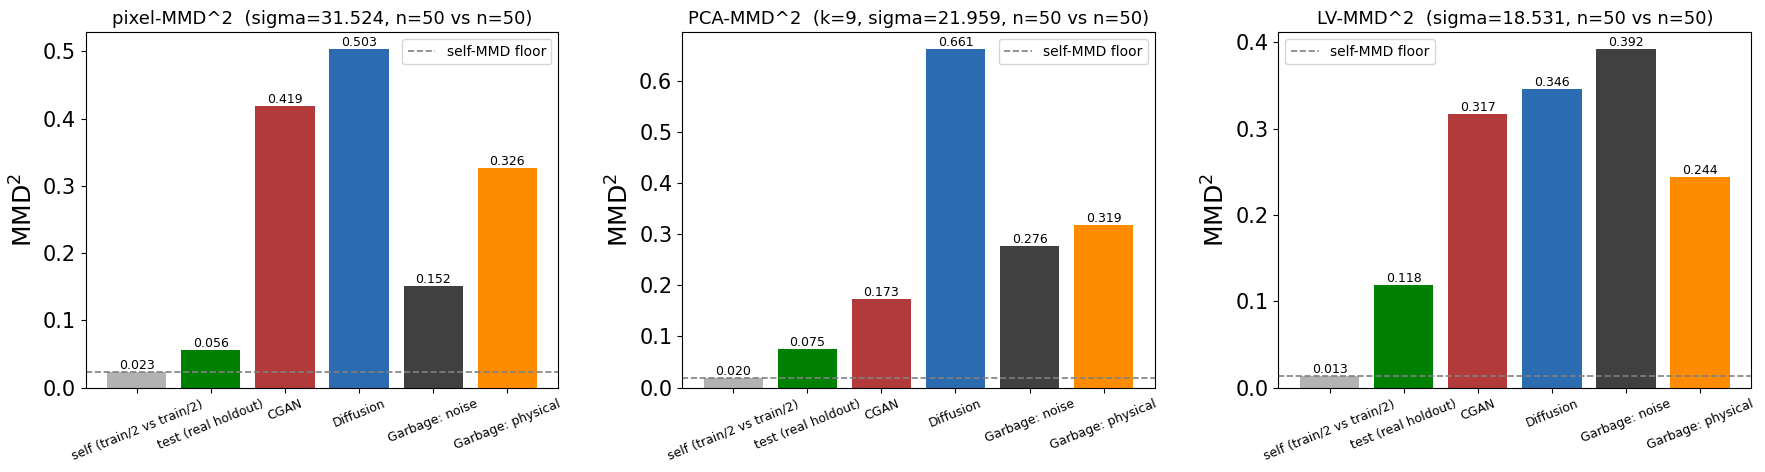

In [13]:
# --- Pixel-MMD vs PCA-MMD vs LV-MMD at matched-N, with self-MMD floor --------
# Bandwidths are fixed once on SIGMA_REF_N train designs and reused everywhere.
# PCA is fit on the same training pool, keeping n_components = len(active_dims)
# so the projection is the closest *linear* analogue of the LVAE active subspace.
from sklearn.decomposition import PCA

ref_idx_full = np.random.default_rng(0).choice(len(x_train), size=SIGMA_REF_N, replace=False)
x_ref_full = enc_train["x"][ref_idx_full]
z_ref_full = enc_train["z_perf"][ref_idx_full][:, active_dims]


def _pix(arr):
    return arr.squeeze(1) if arr.ndim == 4 else arr


n_pca = len(active_dims)
x_train_pix_flat = _pix(enc_train["x"]).reshape(len(enc_train["x"]), -1)
pca = PCA(n_components=n_pca, random_state=0).fit(x_train_pix_flat)


def _to_pca(arr):
    return pca.transform(arr.reshape(len(arr), -1))


x_ref_pca = _to_pca(x_ref_full)

sigma_pixel = metrics.compute_median_sigma(x_ref_full.reshape(SIGMA_REF_N, -1))
sigma_pca = metrics.compute_median_sigma(x_ref_pca)
sigma_latent = metrics.compute_median_sigma(z_ref_full)
print(f"FIXED bandwidths (median heuristic, n={SIGMA_REF_N}):")
print(f"  sigma_pixel  = {sigma_pixel:.4f}   (D = {H * W})")
print(f"  sigma_pca    = {sigma_pca:.4f}   (D = {n_pca})")
print(f"  sigma_latent = {sigma_latent:.4f}   (D = {len(active_dims)})")


def _subsample(arr: np.ndarray, n: int, seed: int) -> np.ndarray:
    """Draw n rows from arr.  Falls back to replacement when len(arr) < n."""
    rng = np.random.default_rng(seed)
    if len(arr) >= n:
        idx = rng.choice(len(arr), size=n, replace=False)
    else:
        idx = rng.choice(len(arr), size=n, replace=True)
        print(f"  [_subsample] pool={len(arr)} < n={n}; sampling with replacement.")
    return arr[idx]


# Build matched-N candidate sets in pixel and active-latent spaces.
# Self-floor uses two disjoint halves of train (seeds 99 & 100), so PIX_SETS["self_a"]
# and LAT_SETS["self_a"] index the same train subset (analogously for self_b).
_n_train = len(enc_train["x"])
if _n_train >= 2 * N_COMMON:
    SELF_A_IDX = np.random.default_rng(99).choice(_n_train, size=N_COMMON, replace=False)
    SELF_B_POOL = np.setdiff1d(np.arange(_n_train), SELF_A_IDX)
    SELF_B_IDX = np.random.default_rng(100).choice(SELF_B_POOL, size=N_COMMON, replace=False)
else:
    print(f"  [self-floor] train pool {_n_train} < 2*N_COMMON={2 * N_COMMON}; using bootstrap halves.")
    SELF_A_IDX = np.random.default_rng(99).choice(_n_train, size=N_COMMON, replace=True)
    SELF_B_IDX = np.random.default_rng(100).choice(_n_train, size=N_COMMON, replace=True)

PIX_SETS = {
    "self_a": _pix(enc_train["x"])[SELF_A_IDX],
    "self_b": _pix(enc_train["x"])[SELF_B_IDX],
    "ref_eval": _subsample(_pix(enc_train["x"]), N_COMMON, 50),
    "test": _subsample(_pix(enc_test["x"]), N_COMMON, 4),
    "cgan": _subsample(_pix(enc_cgan["x"]), N_COMMON, 0),
    "diff": _subsample(_pix(enc_diff["x"]), N_COMMON, 1),
    "noise": _subsample(_pix(enc_noise["x"]), N_COMMON, 2),
    "phys": _subsample(_pix(enc_phys["x"]), N_COMMON, 3),
}
# Transform the *same* pixel subsamples into PCA space so the comparison
# stays index-aligned with PIX_SETS and LAT_SETS.
PCA_SETS = {k: _to_pca(v) for k, v in PIX_SETS.items()}
LAT_SETS = {
    "self_a": enc_train["z_perf"][:, active_dims][SELF_A_IDX],
    "self_b": enc_train["z_perf"][:, active_dims][SELF_B_IDX],
    "ref_eval": _subsample(enc_train["z_perf"][:, active_dims], N_COMMON, 50),
    "test": _subsample(enc_test["z_perf"][:, active_dims], N_COMMON, 4),
    "cgan": _subsample(enc_cgan["z_perf"][:, active_dims], N_COMMON, 0),
    "diff": _subsample(enc_diff["z_perf"][:, active_dims], N_COMMON, 1),
    "noise": _subsample(enc_noise["z_perf"][:, active_dims], N_COMMON, 2),
    "phys": _subsample(enc_phys["z_perf"][:, active_dims], N_COMMON, 3),
}

mmd_rows = [
    ("self (train/2 vs train/2)", "self_a", "self_b"),
    ("test (real holdout)", "test", "ref_eval"),
    ("CGAN", "cgan", "ref_eval"),
    ("Diffusion", "diff", "ref_eval"),
    ("Garbage: noise", "noise", "ref_eval"),
    ("Garbage: physical", "phys", "ref_eval"),
]
# Tuple layout (label, pix, lat, pca) -- LV-MMD stays at index 2 so cell 35,
# which reads mmd_table[i][2], keeps working without modification.
mmd_table = []
for label, a, b in mmd_rows:
    mmd_table.append(
        (
            label,
            metrics.mmd(PIX_SETS[a], PIX_SETS[b], sigma=sigma_pixel),
            metrics.mmd(LAT_SETS[a], LAT_SETS[b], sigma=sigma_latent),
            metrics.mmd(PCA_SETS[a], PCA_SETS[b], sigma=sigma_pca),
        )
    )

print(f"\nALL MMDs:  n_candidate = n_reference = N_COMMON = {N_COMMON}")
print(f"{'set':30s}  {'pixel-MMD^2':>12s}  {'PCA-MMD^2':>12s}  {'LV-MMD^2':>12s}")
print("-" * 76)
for label, pix, lat, pca_v in mmd_table:
    print(f"{label:30s}  {pix:12.4f}  {pca_v:12.4f}  {lat:12.4f}")

# Bar chart with self-MMD floor: pixel -> PCA -> LV-MMD (linear -> linear-proj -> learned)
fig, axes = plt.subplots(1, 3, figsize=(18.0, 5.0))
labels = [r[0] for r in mmd_table]
colors = ["0.7", "green", "#b33a3a", "#2b6cb0", "0.25", "darkorange"]
self_pix, self_lat, self_pca = mmd_table[0][1], mmd_table[0][2], mmd_table[0][3]
panels = [
    (1, f"pixel-MMD^2  (sigma={sigma_pixel:.3f}, n={N_COMMON} vs n={N_COMMON})", self_pix),
    (3, f"PCA-MMD^2  (k={n_pca}, sigma={sigma_pca:.3f}, n={N_COMMON} vs n={N_COMMON})", self_pca),
    (2, f"LV-MMD^2  (sigma={sigma_latent:.3f}, n={N_COMMON} vs n={N_COMMON})", self_lat),
]
for ax, (key, title, ref) in zip(axes, panels):
    vals = [r[key] for r in mmd_table]
    ax.bar(labels, vals, color=colors)
    ax.axhline(ref, color="0.5", ls="--", lw=1.2, label="self-MMD floor")
    ax.set_title(title, fontsize=13)
    ax.set_ylabel("MMD$^2$")
    ax.tick_params(axis="x", rotation=22, labelsize=9)
    for i, v in enumerate(vals):
        ax.text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)
    ax.legend(loc="best", fontsize=10)
fig.tight_layout()
save_vec(fig, "mmd_bars")
plt.show()

saved: ../../paper/figures/lvmmd_sigma_sweep.{pdf,svg,png}


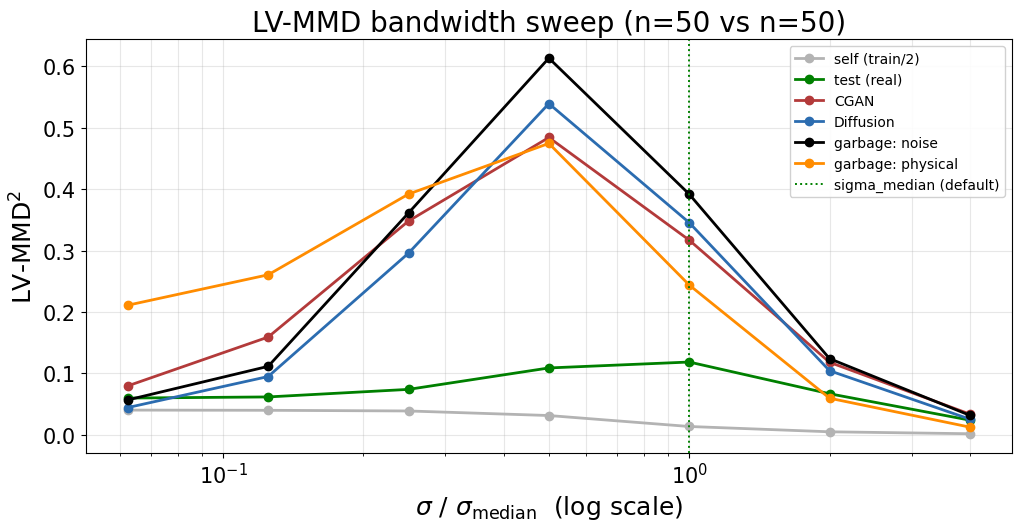

set                     sig/sigm= 0.06  sig/sigm= 0.12  sig/sigm= 0.25  sig/sigm= 0.50  sig/sigm= 1.00  sig/sigm= 2.00  sig/sigm= 4.00
--------------------------------------------------------------------------------------------------------------------------------------
self (train/2)                  0.0400          0.0396          0.0385          0.0311          0.0132          0.0046          0.0014
test (real)                     0.0596          0.0614          0.0737          0.1087          0.1183          0.0666          0.0236
CGAN                            0.0795          0.1590          0.3481          0.4843          0.3170          0.1179          0.0334
Diffusion                       0.0441          0.0947          0.2958          0.5395          0.3455          0.1042          0.0251
garbage: noise                  0.0566          0.1113          0.3613          0.6136          0.3919          0.1238          0.0314
garbage: physical               0.2109          0.2605 

In [14]:
# --- LV-MMD bandwidth sweep ---------------------------------------------------
# At sigma ~ sigma_median, a tightly-clustered (collapsed) candidate can score
# below a real generator because the kernel cannot resolve scales smaller than
# sigma.  The sweep recovers the signal at smaller sigma.

sigma_grid = sigma_latent * np.array([1 / 16, 1 / 8, 1 / 4, 1 / 2, 1.0, 2.0, 4.0])


def _sweep(za, zb):
    return np.array([metrics.mmd(za, zb, sigma=float(s)) for s in sigma_grid])


sweep_rows = {
    "self (train/2)": _sweep(LAT_SETS["self_a"], LAT_SETS["self_b"]),
    "test (real)": _sweep(LAT_SETS["test"], LAT_SETS["ref_eval"]),
    "CGAN": _sweep(LAT_SETS["cgan"], LAT_SETS["ref_eval"]),
    "Diffusion": _sweep(LAT_SETS["diff"], LAT_SETS["ref_eval"]),
    "garbage: noise": _sweep(LAT_SETS["noise"], LAT_SETS["ref_eval"]),
    "garbage: physical": _sweep(LAT_SETS["phys"], LAT_SETS["ref_eval"]),
}

COLOURS = {
    "self (train/2)": "0.7",
    "test (real)": "green",
    "CGAN": "#b33a3a",
    "Diffusion": "#2b6cb0",
    "garbage: noise": "black",
    "garbage: physical": "darkorange",
}

fig, ax = plt.subplots(figsize=(10.5, 5.6))
for label, vals in sweep_rows.items():
    ax.plot(sigma_grid / sigma_latent, vals, "-o", lw=2.0, ms=6, color=COLOURS[label], label=label)
ax.axvline(1.0, color="green", ls=":", lw=1.4, label="sigma_median (default)")
ax.set_xscale("log")
ax.set_xlabel(r"$\sigma$ / $\sigma_{\mathrm{median}}$  (log scale)")
ax.set_ylabel("LV-MMD$^2$")
ax.set_title(f"LV-MMD bandwidth sweep (n={N_COMMON} vs n={N_COMMON})")
ax.legend(loc="best", fontsize=10, framealpha=0.9)
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
save_vec(fig, "lvmmd_sigma_sweep")
plt.show()

print(f"{'set':22s}  " + "  ".join(f"sig/sigm={s / sigma_latent:5.2f}" for s in sigma_grid))
print("-" * (22 + 16 * len(sigma_grid)))
for label, vals in sweep_rows.items():
    print(f"{label:22s}  " + "  ".join(f"{v:14.4f}" for v in vals))

## Contribution&nbsp;2 &mdash; Projection residual (per-sample manifold distance)

A single number per sample: the L2 (or MSE) distance between the generated
design and the PLVAE projection. Large residual = the encoder had to push the
sample far to land on the learned manifold.

The histogram + AUROC pair shows the residual already separates real
generators from garbage at a per-sample level. The decoder-floor figure
calibrates the lower bound: even *real* test designs have a non-zero residual,
and that floor is the ceiling of crispness for any decoded design.


saved: ../../paper/figures/residual_histogram.{pdf,svg,png}


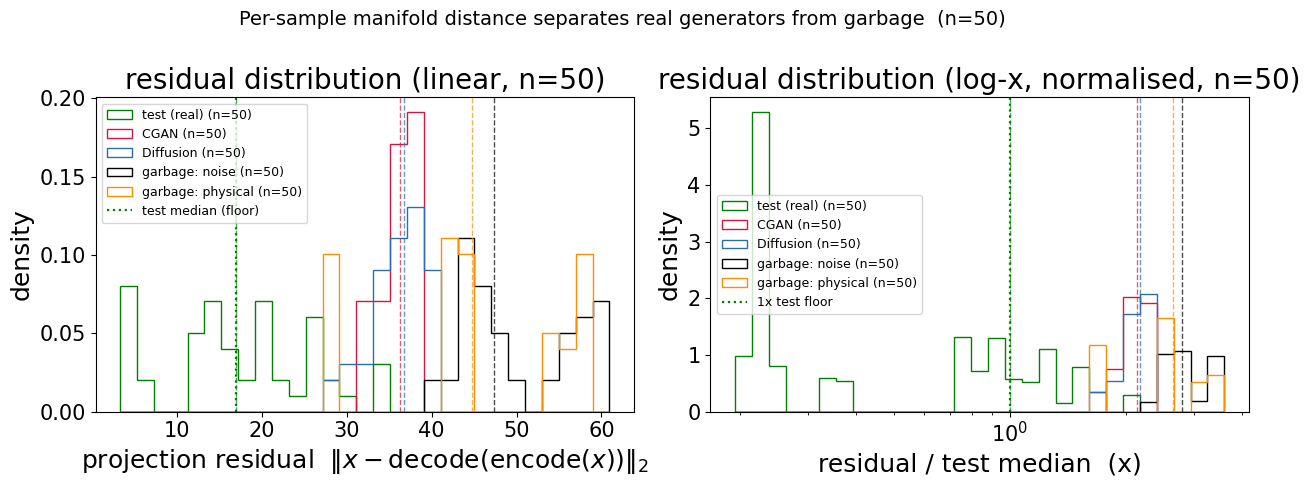


group                      n    median (raw)   median (xfloor)    p95 (xfloor)
--------------------------------------------------------------------------------
test (real)               50           16.95              1.00            1.87
CGAN                      50           36.20              2.14            2.23
Diffusion                 50           36.77              2.17            2.37
garbage: noise            50           47.38              2.80            3.53
garbage: physical         50           44.80              2.64            3.40

AUROC scores (every comparison balanced n=50 vs n=50):
  noise vs. test       : 1.000
  physical vs. test    : 0.984
  noise vs. CGAN       : 1.000
  noise vs. Diffusion  : 0.998
  CGAN vs. Diffusion   : 0.441  (0.5 = no signal)


In [15]:
# --- Per-sample residual histograms + AUROC ----------------------------------
# Residuals are pre-computed in cell 11 (proj_res_l2 = pixel-space L2).


def _take(arr, n, seed):
    """Draw n rows from arr.  Falls back to replacement when len(arr) < n."""
    rng = np.random.default_rng(seed)
    replace = len(arr) < n
    return arr[rng.choice(len(arr), size=n, replace=replace)]


groups_res = [
    ("test (real)", _take(enc_test["proj_res_l2"], N_COMMON, 10), "green"),
    ("CGAN", _take(enc_cgan["proj_res_l2"], N_COMMON, 11), "crimson"),
    ("Diffusion", _take(enc_diff["proj_res_l2"], N_COMMON, 12), "#2b6cb0"),
    ("garbage: noise", _take(enc_noise["proj_res_l2"], N_COMMON, 13), "black"),
    ("garbage: physical", _take(enc_phys["proj_res_l2"], N_COMMON, 14), "darkorange"),
]
floor = float(np.median(groups_res[0][1]))

fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.0))

# Linear-x raw residual
ax = axes[0]
all_vals = np.concatenate([g[1] for g in groups_res])
bins_lin = np.linspace(all_vals.min(), all_vals.max() * 1.02, 30)
for label, vals, colour in groups_res:
    ax.hist(vals, bins=bins_lin, histtype="step", color=colour, lw=2.0, label=f"{label} (n={len(vals)})", density=True)
    ax.axvline(np.median(vals), color=colour, ls="--", lw=1.0, alpha=0.7)
ax.axvline(floor, color="green", ls=":", lw=1.6, label="test median (floor)")
ax.set_xlabel(r"projection residual  $\|x - \mathrm{decode}(\mathrm{encode}(x))\|_2$")
ax.set_ylabel("density")
ax.set_title(f"residual distribution (linear, n={N_COMMON})")
ax.legend(loc="best", fontsize=9)

# Log-x, normalised to the test floor
ax = axes[1]
norm_groups = [(g[0], g[1] / floor, g[2]) for g in groups_res]
all_norm = np.concatenate([g[1] for g in norm_groups])
bins_log = np.geomspace(max(all_norm.min(), 1e-2), all_norm.max() * 1.02, 30)
for label, vals, colour in norm_groups:
    ax.hist(vals, bins=bins_log, histtype="step", color=colour, lw=2.0, label=f"{label} (n={len(vals)})", density=True)
    ax.axvline(np.median(vals), color=colour, ls="--", lw=1.0, alpha=0.7)
ax.axvline(1.0, color="green", ls=":", lw=1.6, label="1x test floor")
ax.set_xscale("log")
ax.set_xlabel("residual / test median  (x)")
ax.set_ylabel("density")
ax.set_title(f"residual distribution (log-x, normalised, n={N_COMMON})")
ax.legend(loc="best", fontsize=9)
fig.suptitle(f"Per-sample manifold distance separates real generators from garbage  (n={N_COMMON})", fontsize=14)
fig.tight_layout()
save_vec(fig, "residual_histogram")
plt.show()


# Numeric summary + AUROC
def _auroc(neg, pos):
    return roc_auc_score(np.r_[np.zeros(len(neg)), np.ones(len(pos))], np.r_[neg, pos])


print(f"\n{'group':22s}  {'n':>4s}  {'median (raw)':>14s}  {'median (xfloor)':>16s}  {'p95 (xfloor)':>14s}")
print("-" * 80)
for label, vals, _ in groups_res:
    print(
        f"{label:22s}  {len(vals):4d}  {np.median(vals):14.2f}  "
        f"{np.median(vals) / floor:16.2f}  {np.percentile(vals, 95) / floor:14.2f}"
    )

test_v = groups_res[0][1]
cgan_v = groups_res[1][1]
diff_v = groups_res[2][1]
noise_v = groups_res[3][1]
phys_v = groups_res[4][1]
print(f"\nAUROC scores (every comparison balanced n={N_COMMON} vs n={N_COMMON}):")
print(f"  noise vs. test       : {_auroc(test_v, noise_v):.3f}")
print(f"  physical vs. test    : {_auroc(test_v, phys_v):.3f}")
print(f"  noise vs. CGAN       : {_auroc(cgan_v, noise_v):.3f}")
print(f"  noise vs. Diffusion  : {_auroc(diff_v, noise_v):.3f}")
print(f"  CGAN vs. Diffusion   : {_auroc(diff_v, cgan_v):.3f}  (0.5 = no signal)")

  [decoder-floor] test pool 40 < N_COMMON=50; using full holdout.
reconstruction-floor diagnostic on N_COMMON = 50 TEST designs:
  nmse_threshold_rec used in training : 0.015
  achieved L2 residual: median=16.97  p95=28.52
  per-pixel L2 (median / sqrt(D)) = 0.1680


/var/folders/lz/sstvj8_j2wdg7941r2fppnt000lf1w/T/ipykernel_97491/4289426676.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.93, 0.96])


saved: ../../paper/figures/decoder_floor.{pdf,svg,png}


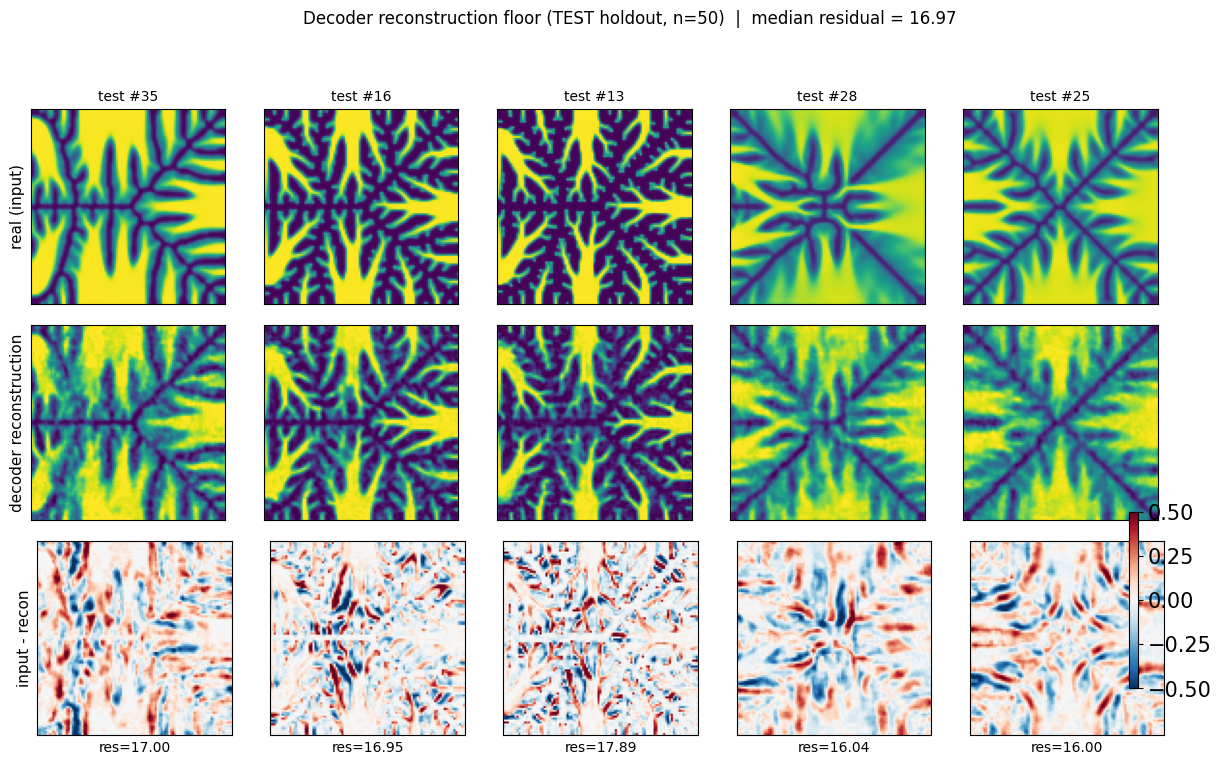

In [16]:
# --- Decoder reconstruction floor on TEST designs -----------------------------
# This is the residual a perfect generator would still produce: the decoder is
# Lipschitz-bounded, so even held-out real designs project with non-zero error.

_floor_n = min(N_COMMON, len(x_test_full))
floor_idx = np.random.default_rng(7).choice(len(x_test_full), size=_floor_n, replace=False)
x_floor = enc_test["x"][floor_idx]
x_floor_proj = enc_test["proj_perf"][floor_idx]
floor_res = enc_test["proj_res_l2"][floor_idx]
if _floor_n < N_COMMON:
    print(f"  [decoder-floor] test pool {_floor_n} < N_COMMON={N_COMMON}; using full holdout.")

print(f"reconstruction-floor diagnostic on N_COMMON = {N_COMMON} TEST designs:")
print(f"  nmse_threshold_rec used in training : {cfg.get('nmse_threshold_rec', '?')}")
print(f"  achieved L2 residual: median={np.median(floor_res):.2f}  p95={np.percentile(floor_res, 95):.2f}")
print(f"  per-pixel L2 (median / sqrt(D)) = {np.median(floor_res) / np.sqrt(H * W):.4f}")

show_idx = np.argsort(np.abs(floor_res - np.median(floor_res)))[:5]

fig, axes = plt.subplots(3, 5, figsize=(13.0, 7.8))
for c, k in enumerate(show_idx):
    pre = x_floor[k]
    post = x_floor_proj[k]
    diff = pre - post
    axes[0, c].imshow(pre, cmap="viridis", vmin=0, vmax=1)
    axes[1, c].imshow(post, cmap="viridis", vmin=0, vmax=1)
    im = axes[2, c].imshow(diff, cmap="RdBu_r", vmin=-0.5, vmax=0.5)
    for r in range(3):
        axes[r, c].set_xticks([])
        axes[r, c].set_yticks([])
    axes[0, c].set_title(f"test #{int(floor_idx[k])}", fontsize=10)
    axes[2, c].set_xlabel(f"res={floor_res[k]:.2f}", fontsize=10)
axes[0, 0].set_ylabel("real (input)", fontsize=11)
axes[1, 0].set_ylabel("decoder reconstruction", fontsize=11)
axes[2, 0].set_ylabel("input - recon", fontsize=11)
fig.colorbar(im, ax=axes[2, :].ravel().tolist(), fraction=0.02, pad=0.02)
fig.suptitle(
    f"Decoder reconstruction floor (TEST holdout, n={N_COMMON})  |  median residual = {np.median(floor_res):.2f}",
    fontsize=12,
)
fig.tight_layout(rect=[0, 0, 0.93, 0.96])
save_vec(fig, "decoder_floor")
plt.show()

## Contribution&nbsp;3 &mdash; Dual-LVAE Gap

The performance-constrained PLVAE and the reconstruction-only LVAE both
project onto the data manifold, but they disagree about which direction is
*important* to preserve. The dual gap is

$$\mathrm{dual\_gap}(x) = \big\lVert \mathrm{decode_{perf}}(\mathrm{encode_{perf}}(x))
                              - \mathrm{decode_{recon}}(\mathrm{encode_{recon}}(x)) \big\rVert^2$$

A *small* gap means both LVAEs returned the same projection &mdash; the original
deviation was cosmetic noise that neither manifold cares about. A *large* gap
means the two projections disagree &mdash; the deviation moved the design in a
performance-relevant direction.

Per-sample the dual gap is the abstract's way of separating "off-manifold but
benign" from "off-manifold and performance-damaging".


saved: ../../paper/figures/dual_gap_histogram.{pdf,svg,png}


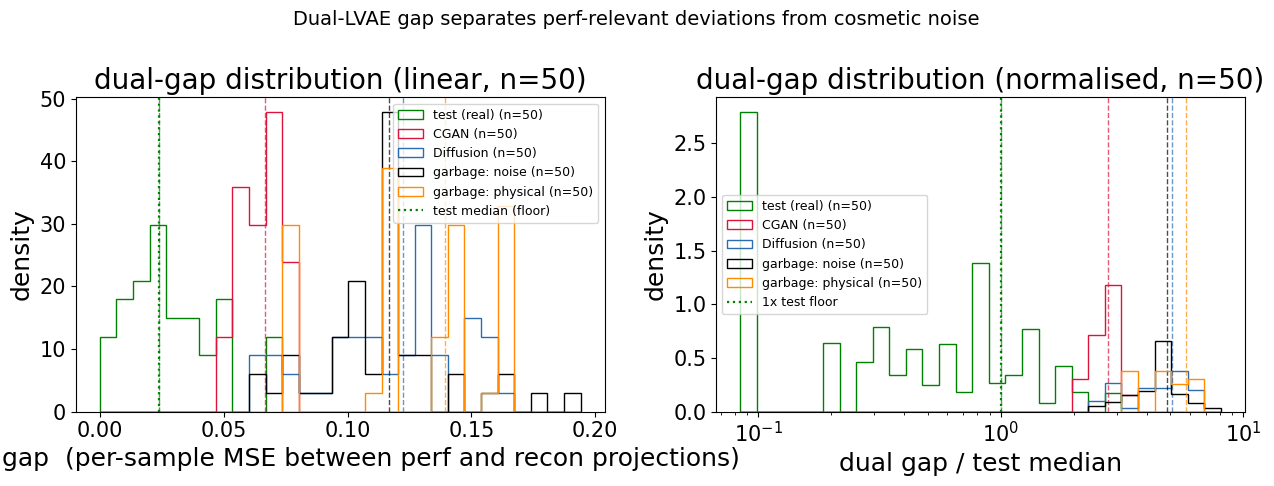


group                      n    median (raw)   median (xfloor)    p95 (xfloor)
--------------------------------------------------------------------------------
test (real)               50        0.024058              1.00            2.81
CGAN                      50        0.066562              2.77            3.15
Diffusion                 50        0.122532              5.09            6.43
garbage: noise            50        0.116903              4.86            6.88
garbage: physical         50        0.139270              5.79            6.75

Dual-gap AUROC scores (n=50 vs n=50):
  noise vs. test       : 0.997
  physical vs. test    : 1.000
  noise vs. CGAN       : 0.968
  noise vs. Diffusion  : 0.442
  CGAN vs. Diffusion   : 0.052


In [17]:
# --- Per-sample dual-gap distributions: real generators vs garbage -----------
groups_dg = [
    ("test (real)", _take(enc_test["dual_gap"], N_COMMON, 30), "green"),
    ("CGAN", _take(enc_cgan["dual_gap"], N_COMMON, 31), "crimson"),
    ("Diffusion", _take(enc_diff["dual_gap"], N_COMMON, 32), "#2b6cb0"),
    ("garbage: noise", _take(enc_noise["dual_gap"], N_COMMON, 33), "black"),
    ("garbage: physical", _take(enc_phys["dual_gap"], N_COMMON, 34), "darkorange"),
]
gap_floor = float(np.median(groups_dg[0][1]))

fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.0))
ax = axes[0]
all_vals = np.concatenate([g[1] for g in groups_dg])
bins_lin = np.linspace(0.0, all_vals.max() * 1.02, 30)
for label, vals, colour in groups_dg:
    ax.hist(vals, bins=bins_lin, histtype="step", color=colour, lw=2.0, label=f"{label} (n={len(vals)})", density=True)
    ax.axvline(np.median(vals), color=colour, ls="--", lw=1.0, alpha=0.7)
ax.axvline(gap_floor, color="green", ls=":", lw=1.6, label="test median (floor)")
ax.set_xlabel(r"dual gap  (per-sample MSE between perf and recon projections)")
ax.set_ylabel("density")
ax.set_title(f"dual-gap distribution (linear, n={N_COMMON})")
ax.legend(loc="best", fontsize=9)

ax = axes[1]
norm_groups = [(g[0], g[1] / max(gap_floor, 1e-12), g[2]) for g in groups_dg]
all_norm = np.concatenate([g[1] for g in norm_groups])
if all_norm.max() / max(all_norm.min(), 1e-3) > 5:
    bins_log = np.geomspace(max(all_norm.min(), 1e-2), all_norm.max() * 1.02, 30)
    ax.set_xscale("log")
else:
    bins_log = np.linspace(0.0, all_norm.max() * 1.02, 30)
for label, vals, colour in norm_groups:
    ax.hist(vals, bins=bins_log, histtype="step", color=colour, lw=2.0, label=f"{label} (n={len(vals)})", density=True)
    ax.axvline(np.median(vals), color=colour, ls="--", lw=1.0, alpha=0.7)
ax.axvline(1.0, color="green", ls=":", lw=1.6, label="1x test floor")
ax.set_xlabel("dual gap / test median")
ax.set_ylabel("density")
ax.set_title(f"dual-gap distribution (normalised, n={N_COMMON})")
ax.legend(loc="best", fontsize=9)

fig.suptitle("Dual-LVAE gap separates perf-relevant deviations from cosmetic noise", fontsize=14)
fig.tight_layout()
save_vec(fig, "dual_gap_histogram")
plt.show()

# Numeric summary + AUROC
print(f"\n{'group':22s}  {'n':>4s}  {'median (raw)':>14s}  {'median (xfloor)':>16s}  {'p95 (xfloor)':>14s}")
print("-" * 80)
for label, vals, _ in groups_dg:
    print(
        f"{label:22s}  {len(vals):4d}  {np.median(vals):14.6f}  "
        f"{np.median(vals) / max(gap_floor, 1e-12):16.2f}  "
        f"{np.percentile(vals, 95) / max(gap_floor, 1e-12):14.2f}"
    )

test_v = groups_dg[0][1]
cgan_v = groups_dg[1][1]
diff_v = groups_dg[2][1]
noise_v = groups_dg[3][1]
phys_v = groups_dg[4][1]
print(f"\nDual-gap AUROC scores (n={N_COMMON} vs n={N_COMMON}):")
print(f"  noise vs. test       : {_auroc(test_v, noise_v):.3f}")
print(f"  physical vs. test    : {_auroc(test_v, phys_v):.3f}")
print(f"  noise vs. CGAN       : {_auroc(cgan_v, noise_v):.3f}")
print(f"  noise vs. Diffusion  : {_auroc(diff_v, noise_v):.3f}")
print(f"  CGAN vs. Diffusion   : {_auroc(diff_v, cgan_v):.3f}")

saved: ../../paper/figures/dual_gap_decomposition.{pdf,svg,png}


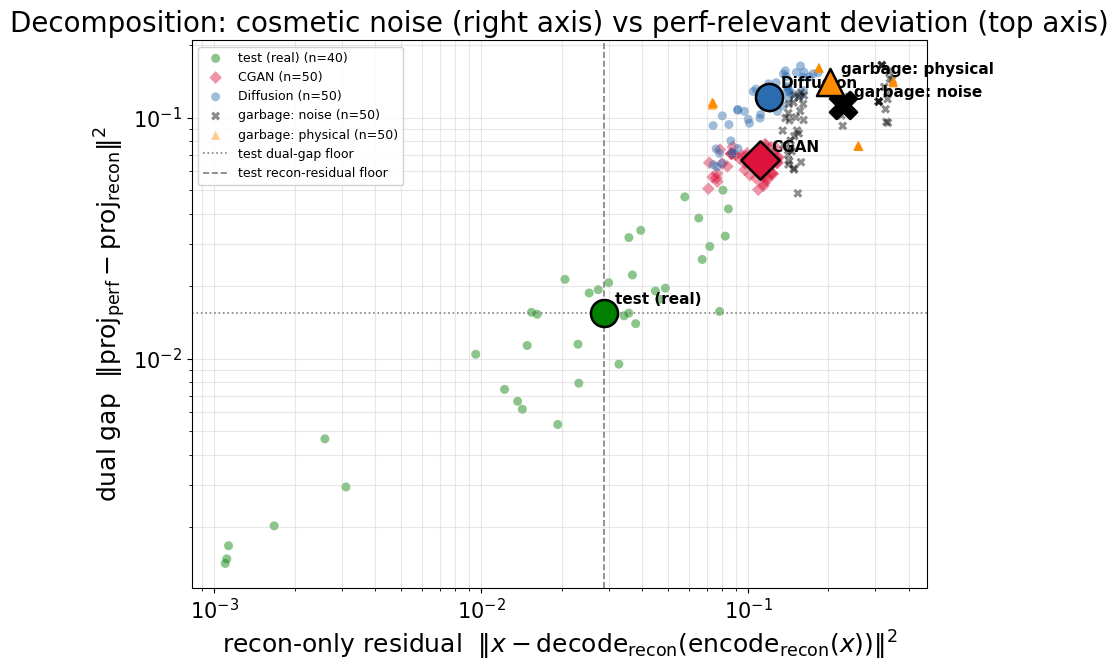

quadrant classification (relative to test medians):
  recon floor = 0.028735    dual-gap floor = 0.015557

  test (real)               low recon    +  low dual-gap    ->  on-manifold, on-perf
  CGAN                      high recon   +  high dual-gap   ->  PERF-RELEVANT deviation
  Diffusion                 high recon   +  high dual-gap   ->  PERF-RELEVANT deviation
  garbage: noise            high recon   +  high dual-gap   ->  PERF-RELEVANT deviation
  garbage: physical         high recon   +  high dual-gap   ->  PERF-RELEVANT deviation


In [18]:
# --- Decomposition scatter: residual_recon  vs  dual_gap ---------------------
# Position on this plane interprets each generator failure mode:
#   bottom-left  = on-manifold, on-perf           (target)
#   bottom-right = COSMETIC noise (high recon residual, low dual gap)
#   top-*        = PERF-RELEVANT deviation (high dual gap, regardless of recon)

fig, ax = plt.subplots(figsize=(9.5, 7.0))

POPS = [
    ("test (real)", enc_test, "green", "o"),
    ("CGAN", enc_cgan, "crimson", "D"),
    ("Diffusion", enc_diff, "#2b6cb0", "o"),
    ("garbage: noise", enc_noise, "black", "X"),
    ("garbage: physical", enc_phys, "darkorange", "^"),
]

# Per-sample scatter, sub-sampled for legibility
for label, enc, colour, marker in POPS:
    n = min(N_COMMON, len(enc["residual_recon"]))
    idx = np.random.default_rng(hash(label) % (2**32)).choice(len(enc["residual_recon"]), size=n, replace=False)
    ax.scatter(
        enc["residual_recon"][idx],
        enc["dual_gap"][idx],
        s=42,
        alpha=0.45,
        c=colour,
        marker=marker,
        edgecolors="none",
        label=f"{label} (n={n})",
    )

# Group medians overlaid as large markers
for label, enc, colour, marker in POPS:
    med_r = float(np.median(enc["residual_recon"]))
    med_g = float(np.median(enc["dual_gap"]))
    ax.scatter(med_r, med_g, s=380, c=colour, marker=marker, edgecolors="black", linewidths=1.8, zorder=5)
    ax.annotate(label, (med_r, med_g), xytext=(8, 6), textcoords="offset points", fontsize=11, fontweight="bold")

ax.axhline(float(np.median(enc_test["dual_gap"])), color="0.5", ls=":", lw=1.2, label="test dual-gap floor")
ax.axvline(float(np.median(enc_test["residual_recon"])), color="0.5", ls="--", lw=1.2, label="test recon-residual floor")
ax.set_xlabel(r"recon-only residual  $\|x - \mathrm{decode_{recon}}(\mathrm{encode_{recon}}(x))\|^2$")
ax.set_ylabel(r"dual gap  $\|\mathrm{proj_{perf}} - \mathrm{proj_{recon}}\|^2$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Decomposition: cosmetic noise (right axis) vs perf-relevant deviation (top axis)")
ax.legend(loc="best", fontsize=9, framealpha=0.9)
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
save_vec(fig, "dual_gap_decomposition")
plt.show()

# Side-effect: print the four-quadrant classification for each set.
test_r_med = float(np.median(enc_test["residual_recon"]))
test_g_med = float(np.median(enc_test["dual_gap"]))
print("quadrant classification (relative to test medians):")
print(f"  recon floor = {test_r_med:.6f}    dual-gap floor = {test_g_med:.6f}\n")
for label, enc, _, _ in POPS:
    r = float(np.median(enc["residual_recon"]))
    g = float(np.median(enc["dual_gap"]))
    horiz = "high recon" if r > 2 * test_r_med else "low recon"
    vert = "high dual-gap" if g > 2 * test_g_med else "low dual-gap"
    if horiz == "low recon" and vert == "low dual-gap":
        verdict = "on-manifold, on-perf"
    elif horiz == "high recon" and vert == "low dual-gap":
        verdict = "COSMETIC noise (recon-only sees it)"
    elif vert == "high dual-gap":
        verdict = "PERF-RELEVANT deviation"
    else:
        verdict = "?"
    print(f"  {label:24s}  {horiz:11s}  +  {vert:14s}  ->  {verdict}")

## Contribution&nbsp;4 &mdash; LV-Projection (encode&ndash;decode as feasibility repair)

The PLVAE encode&ndash;decode pipeline can stand alone as a *post-processing
step*: feed in a noisy generated design, and the on-manifold projection comes
back out. This section visualises the repair on a single sample (driven by
`HIGHLIGHT_IDX` from the config), then quantifies whether it actually helps a
downstream optimiser.

The triptych below uses `HIGHLIGHT_IDX` from the config cell. Re-running this
section after editing the config swaps the displayed sample everywhere.


saved: ../../paper/figures/pre_post_projection.{pdf,svg,png}


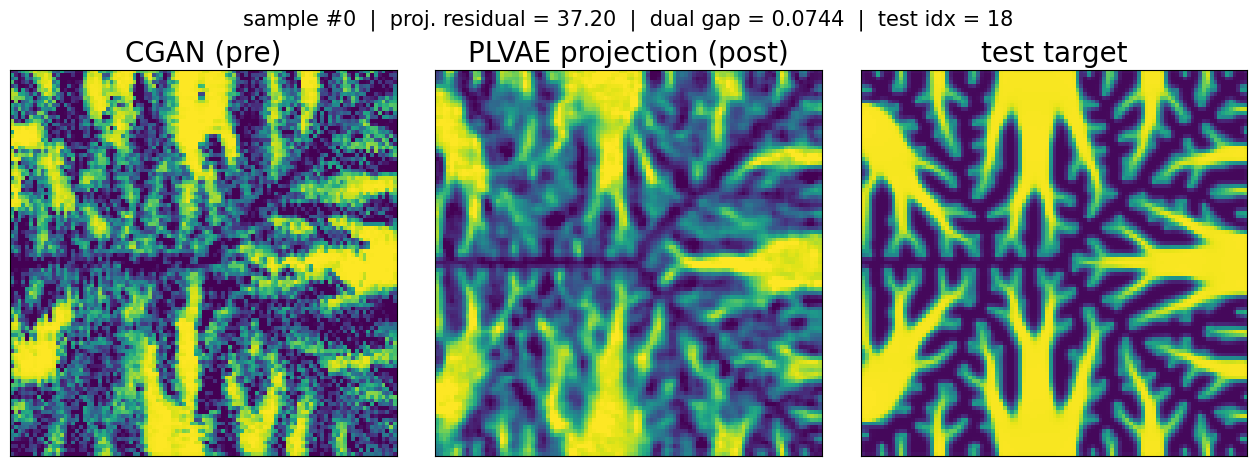

saved: ../../paper/figures/panel_pre.{pdf,svg,png}
saved: ../../paper/figures/panel_post.{pdf,svg,png}
saved: ../../paper/figures/panel_target.{pdf,svg,png}
saved: ../../paper/figures/cgan_vs_diffusion_pre_post.{pdf,svg,png}


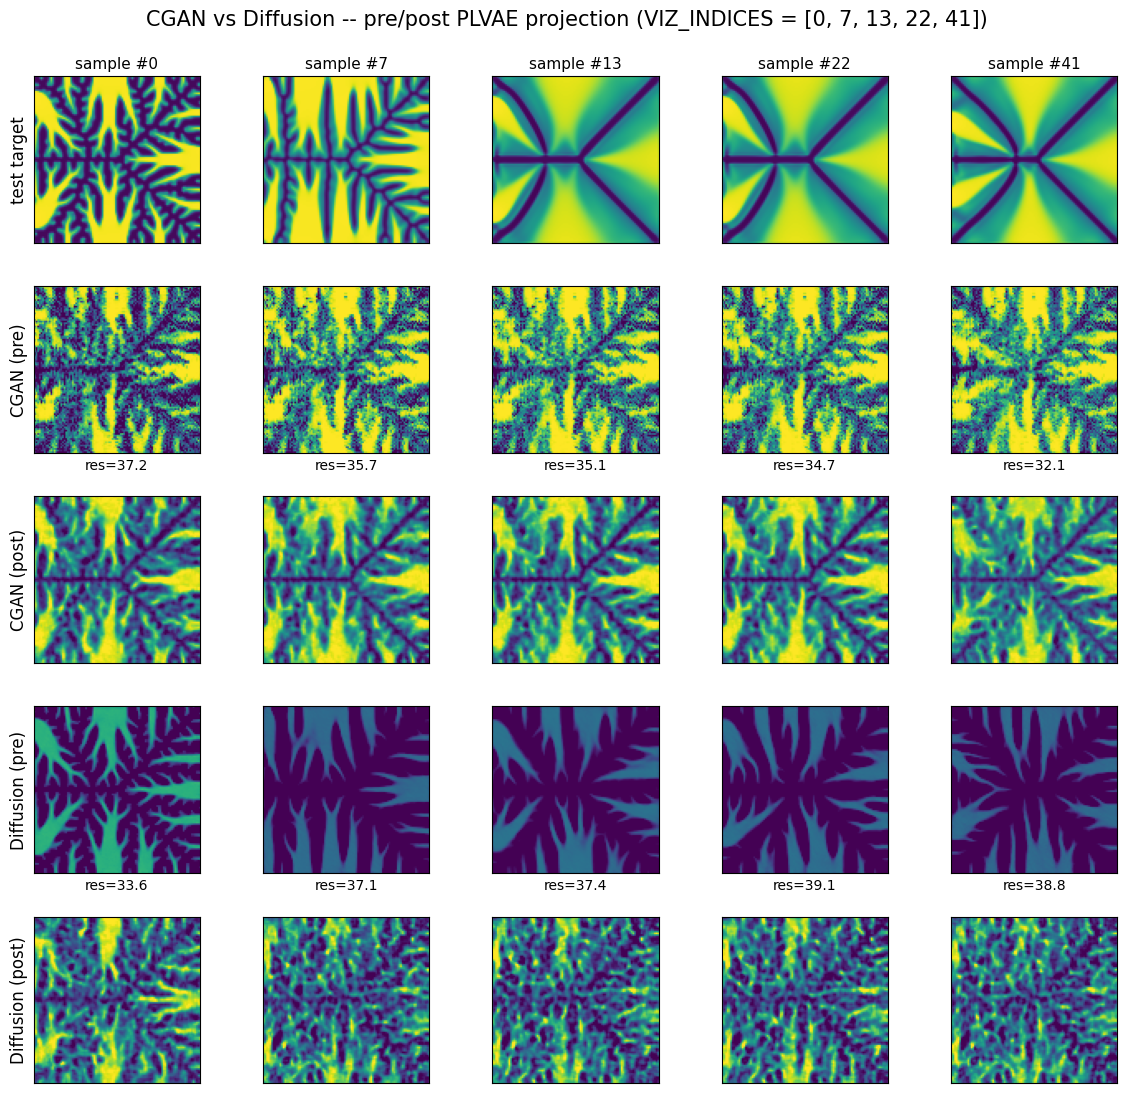

In [19]:
# --- HIGHLIGHT_IDX-driven CGAN / projection / target triptych -----------------
CMAP_PIX = "viridis"
H, W = design_shape

pre_img = enc_cgan["x"][HIGHLIGHT_IDX].reshape(H, W)
post_img = enc_cgan["proj_perf"][HIGHLIGHT_IDX].reshape(H, W)
target_img = enc_targets["x"][HIGHLIGHT_IDX].reshape(H, W)

fig, axes = plt.subplots(1, 3, figsize=(13.0, 4.8))
for ax, img, title in zip(axes, (pre_img, post_img, target_img), ("CGAN (pre)", "PLVAE projection (post)", "test target")):
    ax.imshow(img, cmap=CMAP_PIX, vmin=0, vmax=1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, fontsize=20)
fig.suptitle(
    f"sample #{HIGHLIGHT_IDX}  |  proj. residual = {enc_cgan['proj_res_l2'][HIGHLIGHT_IDX]:.2f}  |  "
    f"dual gap = {enc_cgan['dual_gap'][HIGHLIGHT_IDX]:.4f}  |  test idx = {int(test_idx[HIGHLIGHT_IDX])}",
    fontsize=15,
)
fig.tight_layout()
save_vec(fig, "pre_post_projection")
plt.show()


def _save_bare(img: np.ndarray, stem: str) -> None:
    f, a = plt.subplots(figsize=(3.0, 3.0))
    a.imshow(img, cmap=CMAP_PIX, vmin=0, vmax=1)
    a.set_xticks([])
    a.set_yticks([])
    for s in a.spines.values():
        s.set_visible(False)
    f.subplots_adjust(left=0, right=1, top=1, bottom=0)
    save_vec(f, stem)
    plt.close(f)


_save_bare(pre_img, "panel_pre")
_save_bare(post_img, "panel_post")
_save_bare(target_img, "panel_target")

# Multi-sample strip driven by VIZ_INDICES.
# Top row = test target (ground-truth optimum) so each column reads as a
# "what should this column converge to" reference; the CGAN/Diffusion rows
# show pre/post-projection alongside it.
n_show = len(VIZ_INDICES)
fig, axes = plt.subplots(5, n_show, figsize=(2.4 * n_show, 11.2))
row_imgs = [enc_targets["x"], enc_cgan["x"], enc_cgan["proj_perf"], enc_diff["x"], enc_diff["proj_perf"]]
row_lbls = ["test target", "CGAN (pre)", "CGAN (post)", "Diffusion (pre)", "Diffusion (post)"]
row_res = [None, enc_cgan["proj_res_l2"], None, enc_diff["proj_res_l2"], None]
for r, (lbl, imgs, res) in enumerate(zip(row_lbls, row_imgs, row_res)):
    for c, idx in enumerate(VIZ_INDICES):
        axes[r, c].imshow(imgs[idx].reshape(H, W), cmap=CMAP_PIX, vmin=0, vmax=1)
        axes[r, c].set_xticks([])
        axes[r, c].set_yticks([])
        if r == 0:
            axes[r, c].set_title(f"sample #{int(idx)}", fontsize=11)
        if res is not None:
            axes[r, c].set_xlabel(f"res={res[idx]:.1f}", fontsize=10)
    axes[r, 0].set_ylabel(lbl, fontsize=12)
fig.suptitle(f"CGAN vs Diffusion -- pre/post PLVAE projection (VIZ_INDICES = {VIZ_INDICES})", fontsize=15)
fig.tight_layout()
save_vec(fig, "cgan_vs_diffusion_pre_post")
plt.show()

In [20]:
# --- Predicted (PLVAE head) vs simulated compliance for HIGHLIGHT_IDX --------
# Confirms the performance head is faithful to the simulator at a single sample.

predictor_lipschitz_scale = cfg.get(
    "predictor_lipschitz_scale",
    cfg.get("predictor_lipschitz_ratio", 1.0) * decoder_lipschitz_scale * math.sqrt(math.prod(design_shape) / n_perf),
)
cond_predictor = cfg.get("conditional_predictor", False)
predictor_input_dim = perf_dim + (len(scalar_cond_keys) if cond_predictor else 0)
predictor = SNMLPPredictor(
    input_dim=predictor_input_dim,
    output_dim=n_perf,
    hidden_dims=tuple(cfg.get("predictor_hidden_dims", (256, 128))),
    lipschitz_scale=predictor_lipschitz_scale,
)
predictor.load_state_dict(ckpt["predictor"])
predictor.eval().to(device)

# Performance scaler (mirror training)
perf_scaler_name = cfg.get("perf_scaler", "robust")
if perf_scaler_name == "quantile":
    p_scaler = QuantileTransformer(output_distribution="normal", n_quantiles=min(len(p_train), 1000))
else:
    p_scaler = RobustScaler()
p_scaler.fit(p_train.numpy())

# Optional condition scaler (mirror training)
if cond_predictor:
    c_train = th.stack([train_ds[k][:] for k in scalar_cond_keys], dim=-1).float()
    c_scaler = RobustScaler().fit(c_train.numpy())
else:
    c_scaler = None


def predict_compliance(z_row: np.ndarray, cond_row_scaled: np.ndarray | None = None) -> float:
    z_t = th.from_numpy(z_row[:perf_dim]).float().unsqueeze(0).to(device)
    if cond_predictor and cond_row_scaled is not None:
        c_t = th.from_numpy(cond_row_scaled).float().unsqueeze(0).to(device)
        inp = th.cat([z_t, c_t], dim=-1)
    else:
        inp = z_t
    with th.no_grad():
        pred_scaled = predictor(inp).cpu().numpy()
    return float(p_scaler.inverse_transform(pred_scaled)[0, 0])


cond_row_raw = np.array([float(sampled_conds[int(HIGHLIGHT_IDX)][k]) for k in scalar_cond_keys])
cond_row_scaled = c_scaler.transform(cond_row_raw.reshape(1, -1))[0] if c_scaler is not None else None

z_cgan_h = enc_cgan["z_perf"][HIGHLIGHT_IDX]
z_diff_h = enc_diff["z_perf"][HIGHLIGHT_IDX]
z_target_h = enc_targets["z_perf"][HIGHLIGHT_IDX]

pred_cgan = predict_compliance(z_cgan_h, cond_row_scaled)
pred_diff = predict_compliance(z_diff_h, cond_row_scaled)
pred_target = predict_compliance(z_target_h, cond_row_scaled)

config_h = {k: v for k, v in zip(sampled_conds.column_names, sampled_conds[int(HIGHLIGHT_IDX)].values())}


def _simulate(design: np.ndarray) -> float:
    problem.reset(seed=42)
    return float(np.asarray(problem.simulate(design.reshape(H, W), config=config_h)).reshape(-1)[0])


actual_cgan = _simulate(enc_cgan["x"][HIGHLIGHT_IDX])
actual_diff = _simulate(enc_diff["x"][HIGHLIGHT_IDX])
actual_post = _simulate(enc_cgan["proj_perf"][HIGHLIGHT_IDX])
actual_target = float(p_test_targets[HIGHLIGHT_IDX, 0])

print(f"\n===== Sample #{HIGHLIGHT_IDX}  |  objective: {obj_keys[0]} =====")
print(f"condition: {config_h}\n")
print(f"{'design':28s}  {'predicted':>14s}  {'actual':>14s}  {'|err|':>12s}")
for name, pred, actual in (
    ("CGAN (pre)", pred_cgan, actual_cgan),
    ("Diffusion (pre)", pred_diff, actual_diff),
    ("PLVAE projection (post)", pred_cgan, actual_post),  # decode(encode(x_gen)) shares z
    ("test target", pred_target, actual_target),
):
    print(f"{name:28s}  {pred:14.4e}  {actual:14.4e}  {abs(pred - actual):12.4e}")


===== Sample #0  |  objective: c =====
condition: {'volume': 0.44999999999999996, 'length': 0.7000000000000001}

design                             predicted          actual         |err|
CGAN (pre)                        2.7297e-05      8.8398e-05    6.1101e-05
Diffusion (pre)                   3.3547e-05      2.4263e-04    2.0908e-04
PLVAE projection (post)           2.7297e-05      4.9877e-05    2.2580e-05
test target                       2.6448e-05      2.6760e-05    3.1193e-07


condition: {'volume': 0.44999999999999996, 'length': 0.7000000000000001}

reference optimum (test target): 2.8346e-05

[CGAN (pre)] running problem.optimize ...
[CGAN (pre)] done in 13.6s  |  steps=17  |  IOG=6.0052e-05  COG=9.0828e-04  FOG=1.1008e-05

[PLVAE projection (post)] running problem.optimize ...
[PLVAE projection (post)] done in 14.0s  |  steps=18  |  IOG=2.1531e-05  COG=3.8783e-04  FOG=5.2686e-06

[Diffusion (pre)] running problem.optimize ...
[Diffusion (pre)] done in 14.5s  |  steps=20  |  IOG=2.1428e-04  COG=2.3377e-03  FOG=4.0402e-05

start                                  IOG           COG           FOG
CGAN (pre)                      6.0052e-05    9.0828e-04    1.1008e-05
PLVAE projection (post)         2.1531e-05    3.8783e-04    5.2686e-06
Diffusion (pre)                 2.1428e-04    2.3377e-03    4.0402e-05

COG change  (post - pre) = -5.2046e-04   ->  projection improved
saved: ../../paper/figures/reoptimise_trajectory.{pdf,svg,png}


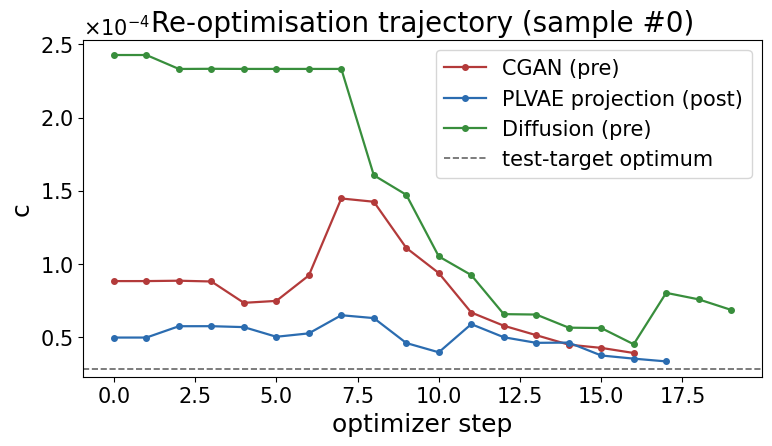


--- panel: re-optimising VIZ_INDICES = [0, 7, 13, 22, 41] (3 starts each) ---

[idx=0] reference optimum = 2.8346e-05
[CGAN (pre)] running problem.optimize ...
[CGAN (pre)] done in 13.2s  |  steps=17  |  IOG=6.0052e-05  COG=9.0828e-04  FOG=1.1008e-05

[PLVAE projection (post)] running problem.optimize ...
[PLVAE projection (post)] done in 14.1s  |  steps=18  |  IOG=2.1531e-05  COG=3.8783e-04  FOG=5.2686e-06

[Diffusion (pre)] running problem.optimize ...
[Diffusion (pre)] done in 13.8s  |  steps=20  |  IOG=2.1428e-04  COG=2.3377e-03  FOG=4.0402e-05

[idx=7] reference optimum = 1.9232e-05
[CGAN (pre)] running problem.optimize ...
[CGAN (pre)] done in 13.4s  |  steps=18  |  IOG=3.1284e-05  COG=9.0209e-04  FOG=2.2156e-05

[PLVAE projection (post)] running problem.optimize ...
[PLVAE projection (post)] done in 13.6s  |  steps=18  |  IOG=2.3127e-05  COG=7.2659e-04  FOG=7.5061e-07

[Diffusion (pre)] running problem.optimize ...
[Diffusion (pre)] done in 13.7s  |  steps=18  |  IOG=2.2843e-03

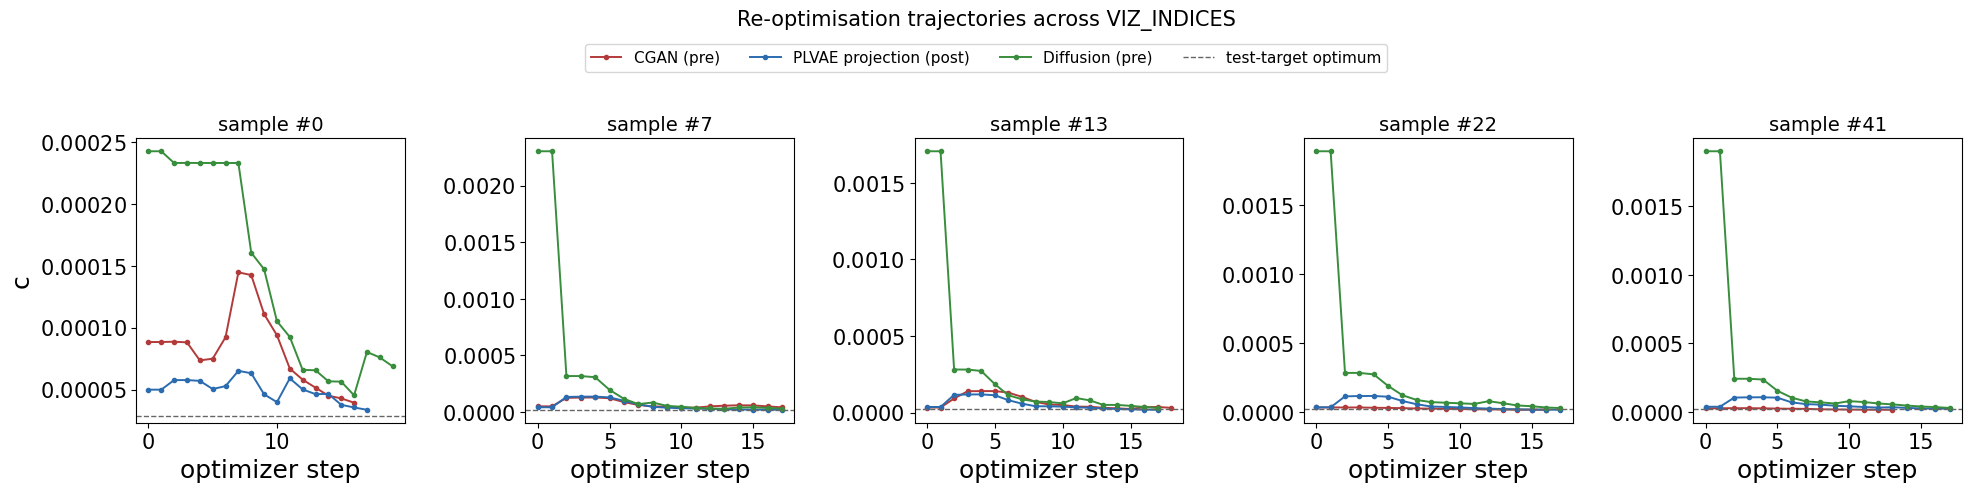


Panel COG summary:
 idx    CGAN-pre COG    PLVAE-post COG    Diff-pre COG    post-pre
   0      9.0828e-04        3.8783e-04      2.3377e-03   -5.20e-04
   7      9.0209e-04        7.2659e-04      6.0196e-03   -1.75e-04
  13      8.4111e-04        5.9079e-04      4.8337e-03   -2.50e-04
  22      8.1691e-05        5.5386e-04      5.2080e-03   +4.72e-04
  41      3.5749e-05        6.2056e-04      5.0603e-03   +5.85e-04


In [21]:
# --- Re-optimise CGAN(pre) vs PLVAE projection(post): does projection lower COG?
from engiopt.metrics import optimality_gap

config_h = {k: v for k, v in zip(sampled_conds.column_names, sampled_conds[int(HIGHLIGHT_IDX)].values())}
print(f"condition: {config_h}\n")

# Reference optimum = simulated compliance of the test-set optimal design
problem.reset(seed=42)
reference_optimum = float(
    np.asarray(problem.simulate(enc_targets["x"][HIGHLIGHT_IDX].reshape(H, W), config=config_h)).reshape(-1)[0]
)
print(f"reference optimum (test target): {reference_optimum:.4e}\n")


def _reoptimise(design_np: np.ndarray, label: str, cfg_i: dict, ref_opt: float) -> dict:
    print(f"[{label}] running problem.optimize ...")
    t0 = time.time()
    problem.reset(seed=42)
    _, history = problem.optimize(design_np.reshape(H, W), config=cfg_i)
    dt = time.time() - t0
    gaps = optimality_gap(history, ref_opt)
    print(
        f"[{label}] done in {dt:.1f}s  |  steps={len(gaps)}  "
        f"|  IOG={gaps[0]:.4e}  COG={float(np.sum(gaps)):.4e}  FOG={gaps[-1]:.4e}\n"
    )
    return {"label": label, "history": history, "gaps": gaps, "iog": gaps[0], "cog": float(np.sum(gaps)), "fog": gaps[-1]}


pre_res = _reoptimise(enc_cgan["x"][HIGHLIGHT_IDX], "CGAN (pre)", config_h, reference_optimum)
post_res = _reoptimise(enc_cgan["proj_perf"][HIGHLIGHT_IDX], "PLVAE projection (post)", config_h, reference_optimum)
diff_res = _reoptimise(enc_diff["x"][HIGHLIGHT_IDX], "Diffusion (pre)", config_h, reference_optimum)

print("=" * 72)
print(f"{'start':28s}  {'IOG':>12s}  {'COG':>12s}  {'FOG':>12s}")
for r in (pre_res, post_res, diff_res):
    print(f"{r['label']:28s}  {r['iog']:12.4e}  {r['cog']:12.4e}  {r['fog']:12.4e}")

dcog = post_res["cog"] - pre_res["cog"]
print(f"\nCOG change  (post - pre) = {dcog:+.4e}   ->  projection {'improved' if dcog < 0 else 'worsened'}")

fig, ax = plt.subplots(figsize=(8.0, 5.0))
for r, colour in ((pre_res, "#b33a3a"), (post_res, "#2b6cb0"), (diff_res, "#388e3c")):
    objs = [float(np.asarray(step.obj_values).reshape(-1)[0]) for step in r["history"]]
    ax.plot(range(len(objs)), objs, "-o", ms=4, lw=1.6, color=colour, label=r["label"])
ax.axhline(reference_optimum, color="0.4", linestyle="--", lw=1.2, label="test-target optimum")
ax.set_xlabel("optimizer step")
ax.set_ylabel(obj_keys[0])
ax.set_title(f"Re-optimisation trajectory (sample #{HIGHLIGHT_IDX})")
ax.legend()
sfmt = ScalarFormatter(useMathText=True)
sfmt.set_scientific(True)
sfmt.set_powerlimits((0, 0))
ax.yaxis.set_major_formatter(sfmt)
fig.tight_layout()
save_vec(fig, "reoptimise_trajectory")
plt.show()


# --- Panel: re-optimise every VIZ_INDICES start in 3 flavours -----------------
# Mirrors the multi-sample strip above so columns line up:
#   col c == VIZ_INDICES[c], same condition, target optimum dashed.
# Each cell runs 3 problem.optimize() calls (CGAN-pre, PLVAE-post, Diff-pre).
print(f"\n--- panel: re-optimising VIZ_INDICES = {VIZ_INDICES} (3 starts each) ---\n")
panel_results: dict[int, dict] = {}
for idx in VIZ_INDICES:
    idx_i = int(idx)
    cfg_i = {k: v for k, v in zip(sampled_conds.column_names, sampled_conds[idx_i].values())}
    problem.reset(seed=42)
    ref_i = float(np.asarray(problem.simulate(enc_targets["x"][idx_i].reshape(H, W), config=cfg_i)).reshape(-1)[0])
    print(f"[idx={idx_i}] reference optimum = {ref_i:.4e}")
    panel_results[idx_i] = {
        "ref": ref_i,
        "pre": _reoptimise(enc_cgan["x"][idx_i], "CGAN (pre)", cfg_i, ref_i),
        "post": _reoptimise(enc_cgan["proj_perf"][idx_i], "PLVAE projection (post)", cfg_i, ref_i),
        "diff": _reoptimise(enc_diff["x"][idx_i], "Diffusion (pre)", cfg_i, ref_i),
    }

n_show = len(VIZ_INDICES)
fig, axes = plt.subplots(1, n_show, figsize=(4.0 * n_show, 4.6), squeeze=False)
axes = axes[0]
COLOURS = {"pre": "#b33a3a", "post": "#2b6cb0", "diff": "#388e3c"}
for ax, idx in zip(axes, VIZ_INDICES):
    res = panel_results[int(idx)]
    for key in ("pre", "post", "diff"):
        r = res[key]
        objs = [float(np.asarray(step.obj_values).reshape(-1)[0]) for step in r["history"]]
        ax.plot(range(len(objs)), objs, "-o", ms=3, lw=1.4, color=COLOURS[key], label=r["label"])
    ax.axhline(res["ref"], color="0.4", linestyle="--", lw=1.0, label="test-target optimum")
    ax.set_title(f"sample #{int(idx)}", fontsize=14)
    ax.set_xlabel("optimizer step")
    ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
axes[0].set_ylabel(obj_keys[0])
# Single legend taken from the first subplot, anchored above the row.
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.02), fontsize=11)
fig.suptitle("Re-optimisation trajectories across VIZ_INDICES", y=1.08, fontsize=15)
fig.tight_layout()
save_vec(fig, "reoptimise_trajectory_panel")
plt.show()

print("\nPanel COG summary:")
print(f"{'idx':>4s}  {'CGAN-pre COG':>14s}  {'PLVAE-post COG':>16s}  {'Diff-pre COG':>14s}  {'post-pre':>10s}")
for idx in VIZ_INDICES:
    r = panel_results[int(idx)]
    d = r["post"]["cog"] - r["pre"]["cog"]
    print(f"{int(idx):>4d}  {r['pre']['cog']:>14.4e}  {r['post']['cog']:>16.4e}  {r['diff']['cog']:>14.4e}  {d:>+10.2e}")

## Validation&nbsp;A &mdash; cheap-metric rankings vs ground-truth COG / IOG

The methodological question of the abstract is **whether cheap LV metrics
reproduce the model-selection decisions a designer would make after running
simulation-based COG.** This section answers it numerically.

For each problem in `PROBLEMS_TO_ANALYSE` × seeds in `SEEDS_TO_ANALYSE`,
we pull the latest evaluation metrics directly from each training run's
WandB summary (the eval pipeline `evaluate_*.py` writes them via
`engiopt.eval_utils.log_lvae_combo_to_wandb`).  Schema:

| key                                                          | meaning |
|---|---|
| `eval/cog`, `eval/cog_median`, `eval/iog`, `eval/iog_median`, ... | ground-truth optimization gaps |
| `eval/mmd`                                                   | pixel-space MMD |
| `eval/lv_rec{rec}_perf{perf}_lvae{seed}/lv_mmd`              | LV-MMD at this PLVAE config |
| `.../lv_proj_residual_mean`                                  | projection residual |
| `.../lv_dual_gap_mean`                                       | dual-LVAE gap |
| `.../lv_dpp`, `.../n_active_dims`                            | latent diversity / active-dim count |

The pull is cached to `wandb_eval_metrics_cache.json` so re-runs are
instant.  Flip `REFRESH_WANDB_CACHE = True` in the config cell to force a
re-fetch (e.g. after a fresh eval sweep finishes).


loaded 80 cached runs from wandb_eval_metrics_cache.json (REFRESH_WANDB_CACHE=True to force a re-pull)

beams2d: 40 runs  | archs: {'cgan_cnn_2d': 10, 'diffusion_2d_cond': 10, 'gan_cnn_2d': 10, 'vqgan': 10}  | runs with COG: 0  | LV configs: 4
heatconduction2d: 40 runs  | archs: {'cgan_cnn_2d': 10, 'diffusion_2d_cond': 10, 'gan_cnn_2d': 10, 'vqgan': 10}  | runs with COG: 0  | LV configs: 6
saved: ../../paper/figures/gt_cog_by_architecture.{pdf,svg,png}


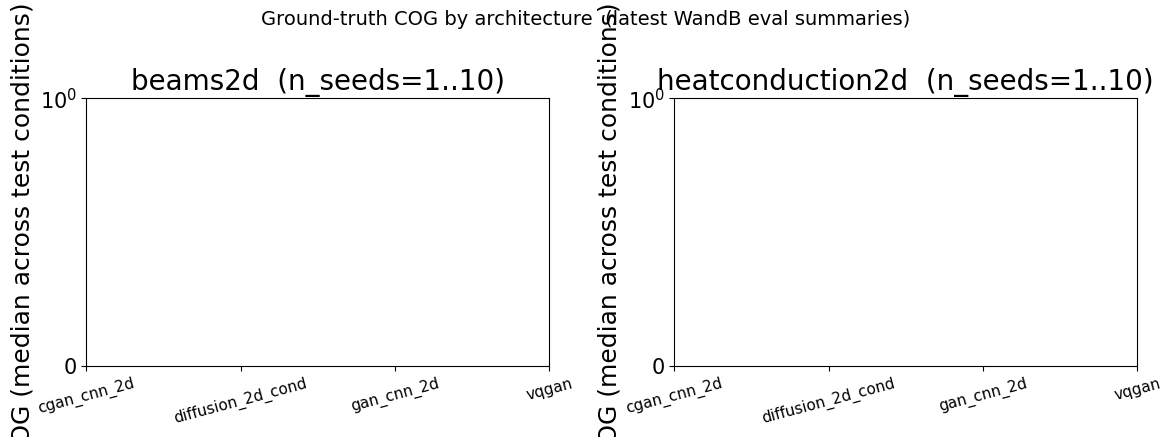

In [22]:
# --- Pull ground-truth + LV metrics from WandB for every (problem, arch, seed) -
# Each training run's `run.summary` is populated by `evaluate_*.py` via
# `engiopt.eval_utils.log_*_to_wandb`.  We anchor on the generator artifact
# (alias `seed_{seed}`), then read its `logged_by()` run's summary.
import json
from pathlib import Path

# Anchor artifact name per architecture (the one whose `logged_by()` is the
# eval-reporting run).  These mirror the patterns in each `evaluate_*.py`.
GENERATOR_ARTIFACTS = {
    "cgan_cnn_2d": "{problem}_cgan_cnn_2d_generator",
    "gan_cnn_2d": "{problem}_gan_cnn_2d_generator",
    "diffusion_2d_cond": "{problem}_diffusion_2d_cond_model",
    "vqgan": "{problem}_vqgan_transformer",
}

PROBLEMS_TO_ANALYSE = ["beams2d", "heatconduction2d"]
SEEDS_TO_ANALYSE = list(range(1, 11))
WANDB_CACHE_PATH = Path("./wandb_eval_metrics_cache.json")
REFRESH_WANDB_CACHE = False  # flip to True to force a fresh pull


def _fetch_run_for(problem: str, arch: str, seed: int) -> dict | None:
    """Return the WandB training run that owns the seed=`seed` generator artifact."""
    name = GENERATOR_ARTIFACTS[arch].format(problem=problem)
    try:
        art = api.artifact(artifact_path(name, f"seed_{seed}"), type="model")
    except Exception as e:  # noqa: BLE001
        print(f"    [{problem} {arch} seed={seed}] artifact not found: {e}")
        return None
    run = art.logged_by()
    if run is None:
        print(f"    [{problem} {arch} seed={seed}] artifact has no logged_by run")
        return None
    return {"run_id": run.id, "summary": dict(run.summary)}


def _flatten(summary: dict) -> dict:
    """Strip the `eval/` prefix so downstream code reads `cog`, `lv_rec*/lv_mmd`, etc."""
    out = {}
    for k, v in summary.items():
        key = k.removeprefix("eval/")
        # Skip wandb-internal media/log keys we never use.
        if isinstance(v, dict) and "_type" in v:
            continue
        out[key] = v
    return out


def _pull_all() -> list[dict]:
    rows = []
    for problem in PROBLEMS_TO_ANALYSE:
        print(f"\nproblem = {problem}")
        for arch in GENERATOR_ARTIFACTS:
            print(f"  arch = {arch}")
            for seed in SEEDS_TO_ANALYSE:
                meta = _fetch_run_for(problem, arch, seed)
                if meta is None:
                    continue
                flat = _flatten(meta["summary"])
                rows.append(
                    {
                        "problem_id": problem,
                        "model_id": arch,
                        "seed": seed,
                        "run_id": meta["run_id"],
                        **flat,
                    }
                )
    return rows


if WANDB_CACHE_PATH.exists() and not REFRESH_WANDB_CACHE:
    raw_runs = json.loads(WANDB_CACHE_PATH.read_text())
    print(f"loaded {len(raw_runs)} cached runs from {WANDB_CACHE_PATH} (REFRESH_WANDB_CACHE=True to force a re-pull)")
else:
    print("pulling fresh eval summaries from WandB ...")
    raw_runs = _pull_all()
    WANDB_CACHE_PATH.write_text(json.dumps(raw_runs, default=str))
    print(f"\nwrote {len(raw_runs)} runs to {WANDB_CACHE_PATH}")

# Per-problem index, plus sanity counts.
gt_runs_by_problem: dict[str, list[dict]] = {p: [] for p in PROBLEMS_TO_ANALYSE}
for r in raw_runs:
    if r["problem_id"] in gt_runs_by_problem:
        gt_runs_by_problem[r["problem_id"]].append(r)

ARCH_COL = {"cgan_cnn_2d": "#b33a3a", "diffusion_2d_cond": "#2b6cb0", "gan_cnn_2d": "darkorange", "vqgan": "purple"}

print()
for prob, runs in gt_runs_by_problem.items():
    archs_here = sorted({r["model_id"] for r in runs})
    counts = {a: sum(1 for r in runs if r["model_id"] == a) for a in archs_here}
    cog_pop = sum(1 for r in runs if r.get("cog") is not None)
    lv_keys = {k.rsplit("/", 1)[0] for r in runs for k in r if k.startswith("lv_rec")}
    print(f"{prob}: {len(runs)} runs  | archs: {counts}  | runs with COG: {cog_pop}  | LV configs: {len(lv_keys)}")

# Side-by-side COG-by-arch boxplot for every problem in PROBLEMS_TO_ANALYSE.
fig, axes = plt.subplots(1, len(PROBLEMS_TO_ANALYSE), figsize=(6.0 * len(PROBLEMS_TO_ANALYSE), 4.5))
if len(PROBLEMS_TO_ANALYSE) == 1:
    axes = [axes]
for ax, prob in zip(axes, PROBLEMS_TO_ANALYSE):
    runs = gt_runs_by_problem[prob]
    archs_here = sorted({r["model_id"] for r in runs})
    for i, arch in enumerate(archs_here):
        vals = np.array([r.get("cog_median") for r in runs if r["model_id"] == arch], dtype=float)
        vals = vals[np.isfinite(vals)]
        if len(vals) == 0:
            continue
        bp = ax.boxplot([vals], positions=[i], widths=0.55, patch_artist=True, showfliers=True)
        for box in bp["boxes"]:
            box.set(facecolor=ARCH_COL.get(arch, "0.6"), alpha=0.6)
        ax.scatter(
            np.full(len(vals), i) + np.random.default_rng(0).uniform(-0.18, 0.18, size=len(vals)),
            vals,
            color=ARCH_COL.get(arch, "0.6"),
            s=42,
            edgecolor="black",
            linewidth=0.6,
            zorder=3,
        )
    ax.set_xticks(range(len(archs_here)))
    ax.set_xticklabels(archs_here, rotation=15, fontsize=11)
    ax.set_ylabel("COG (median across test conditions)")
    ax.set_yscale("symlog")
    ax.set_title(f"{prob}  (n_seeds=1..{max(SEEDS_TO_ANALYSE)})")
fig.suptitle("Ground-truth COG by architecture  (latest WandB eval summaries)", fontsize=14)
fig.tight_layout()
save_vec(fig, "gt_cog_by_architecture")
plt.show()

In [23]:
# --- Build (problem, LV config) -> ranking_runs from the cached WandB summaries
# Each WandB run summary has one `lv_rec{rec}_perf{perf}_lvae{lvae_seed}/...`
# block per (rec, perf) combo the eval script ran.  We auto-detect those
# prefixes per problem so the analysis adapts to whatever sweep is logged.
from typing import Any

CHEAP_METRIC_KEYS = {
    "lv_mmd": "lv_mmd",
    "lv_residual": "lv_proj_residual_mean",
    "lv_dual_gap": "lv_dual_gap_mean",
    "lv_dpp": "lv_dpp",
    "n_active": "n_active_dims",
}
GROUND_TRUTH_KEYS = ["cog", "iog", "fog", "cog_median", "iog_median", "fog_median"]


def _detect_prefixes(runs: list[dict]) -> list[str]:
    """Union of `lv_rec*_perf*_lvae*` prefixes that appear in at least one run."""
    pref = set()
    for r in runs:
        for k in r:
            if k.startswith("lv_rec") and "/" in k:
                pref.add(k.rsplit("/", 1)[0])
    return sorted(pref)


def _build_ranking_rows(runs: list[dict], prefix: str) -> list[dict]:
    rows = []
    for r in runs:
        row: dict[str, Any] = {
            "run_id": r.get("run_id"),
            "problem_id": r.get("problem_id"),
            "model_id": r.get("model_id"),
            "seed": r.get("seed"),
            "pixel_mmd": r.get("mmd"),
        }
        for g in GROUND_TRUTH_KEYS:
            row[g] = r.get(g)
        for short, suffix in CHEAP_METRIC_KEYS.items():
            row[short] = r.get(f"{prefix}/{suffix}")
        rows.append(row)
    return rows


ranking_runs_by_problem: dict[str, dict[str, list[dict]]] = {}
lv_prefixes_by_problem: dict[str, list[str]] = {}
for prob, runs in gt_runs_by_problem.items():
    prefixes = _detect_prefixes(runs)
    lv_prefixes_by_problem[prob] = prefixes
    ranking_runs_by_problem[prob] = {p: _build_ranking_rows(runs, p) for p in prefixes}

# Sanity: how many runs have a finite lv_mmd, per (problem, prefix)?
print(f"{'problem':22s}  {'prefix':50s}  {'finite_lv_mmd':>14s}  {'finite_cog':>11s}")
print("-" * 105)
for prob, by_prefix in ranking_runs_by_problem.items():
    for prefix, rows in by_prefix.items():
        n_lv = sum(1 for r in rows if r.get("lv_mmd") is not None and np.isfinite(float(r.get("lv_mmd") or np.nan)))
        n_cog = sum(1 for r in rows if r.get("cog") is not None and np.isfinite(float(r.get("cog") or np.nan)))
        print(f"{prob:22s}  {prefix:50s}  {n_lv:>14d}  {n_cog:>11d}")

problem                 prefix                                               finite_lv_mmd   finite_cog
---------------------------------------------------------------------------------------------------------
beams2d                 lv_rec0.001_perf0.01_lvae1                                      40            0
beams2d                 lv_rec0.001_perf1000.0_lvae1                                    40            0
beams2d                 lv_rec0.005_perf0.01_lvae1                                      40            0
beams2d                 lv_rec0.005_perf1000.0_lvae1                                    40            0
heatconduction2d        lv_rec0.015_perf0.01_lvae1                                      40            0
heatconduction2d        lv_rec0.015_perf1000.0_lvae1                                    40            0
heatconduction2d        lv_rec0.01_perf0.01_lvae1                                       40            0
heatconduction2d        lv_rec0.01_perf1000.0_lvae1           

 BEAMS2D  --  pooled rank correlations  (rows = cheap metric, cols = GT)

--- lv_rec0.001_perf0.01_lvae1 | pooled  (n = 40) ---
cheap metric        cog_median      iog_median      fog_median
lv_mmd                n=0             n=0             n=0     
lv_residual           n=0             n=0             n=0     
lv_dual_gap           n=0             n=0             n=0     
lv_dpp                n=0             n=0             n=0     
pixel_mmd             n=0             n=0             n=0     

--- lv_rec0.001_perf1000.0_lvae1 | pooled  (n = 40) ---
cheap metric        cog_median      iog_median      fog_median
lv_mmd                n=0             n=0             n=0     
lv_residual           n=0             n=0             n=0     
lv_dual_gap           n=0             n=0             n=0     
lv_dpp                n=0             n=0             n=0     
pixel_mmd             n=0             n=0             n=0     

--- lv_rec0.005_perf0.01_lvae1 | pooled  (n = 40) ---
chea

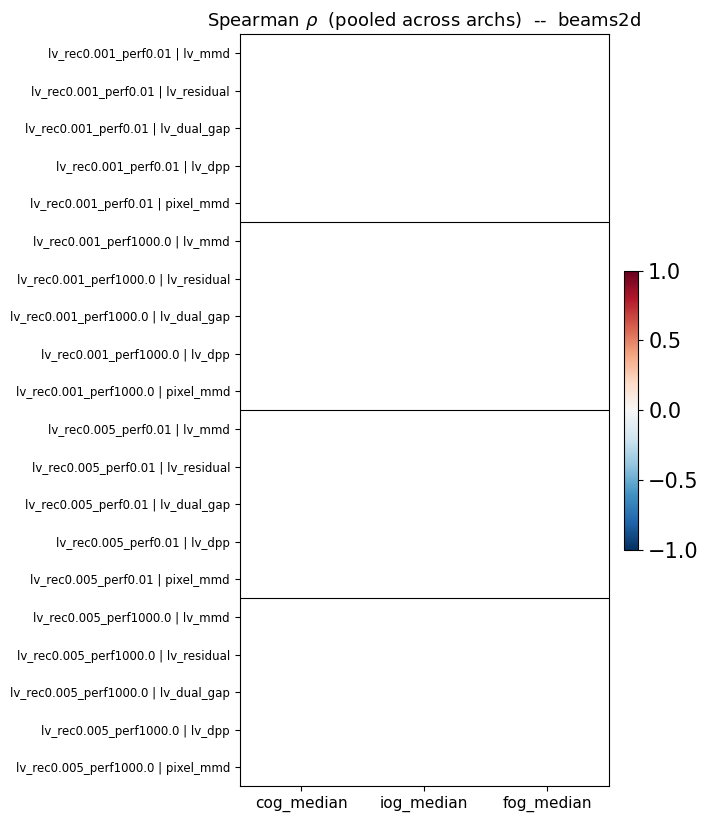

saved: ../../paper/figures/rank_correlation_heatmap_beams2d_per_arch.{pdf,svg,png}


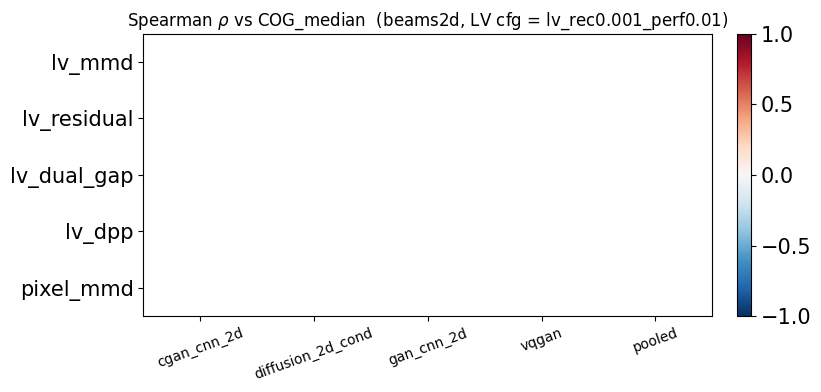

 HEATCONDUCTION2D  --  pooled rank correlations  (rows = cheap metric, cols = GT)

--- lv_rec0.015_perf0.01_lvae1 | pooled  (n = 40) ---
cheap metric        cog_median      iog_median      fog_median
lv_mmd                n=0             n=0             n=0     
lv_residual           n=0             n=0             n=0     
lv_dual_gap           n=0             n=0             n=0     
lv_dpp                n=0             n=0             n=0     
pixel_mmd             n=0             n=0             n=0     

--- lv_rec0.015_perf1000.0_lvae1 | pooled  (n = 40) ---
cheap metric        cog_median      iog_median      fog_median
lv_mmd                n=0             n=0             n=0     
lv_residual           n=0             n=0             n=0     
lv_dual_gap           n=0             n=0             n=0     
lv_dpp                n=0             n=0             n=0     
pixel_mmd             n=0             n=0             n=0     

--- lv_rec0.01_perf0.01_lvae1 | pooled  (n = 40) 

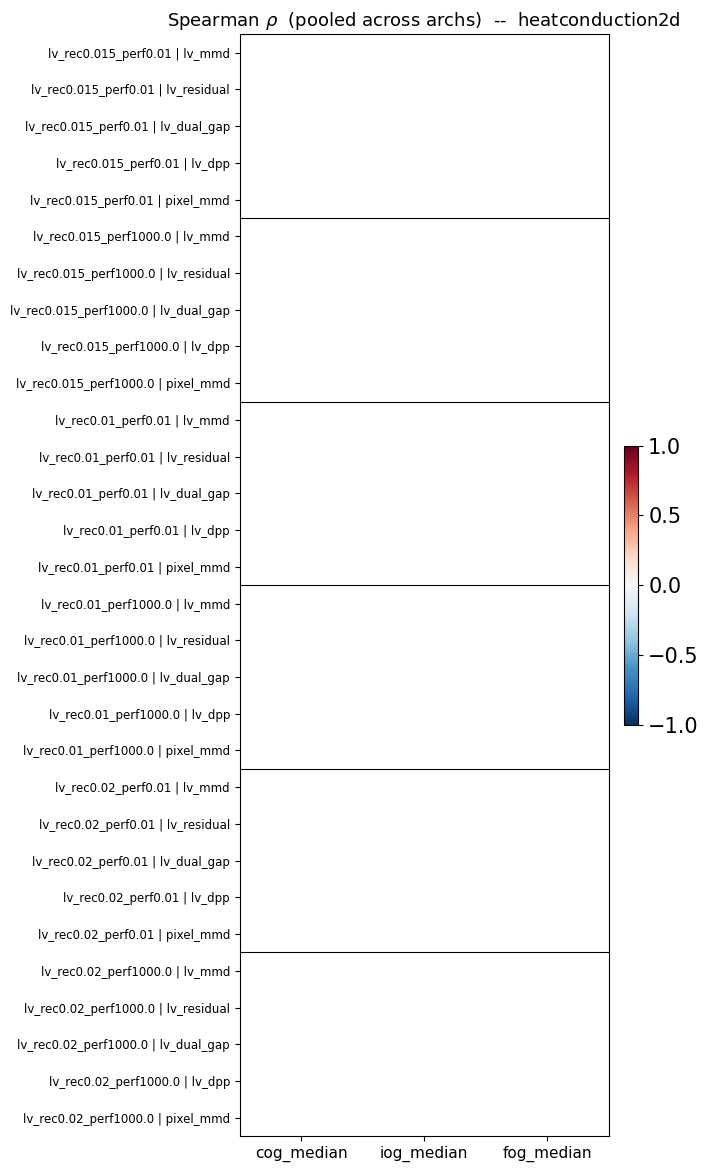

saved: ../../paper/figures/rank_correlation_heatmap_heatconduction2d_per_arch.{pdf,svg,png}


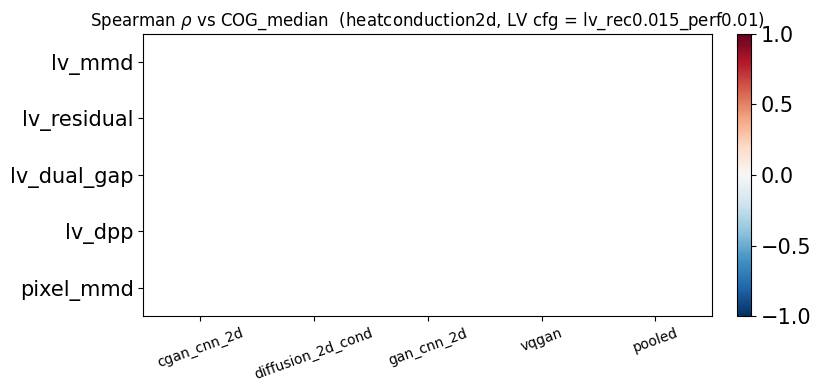

In [24]:
# --- Spearman / Kendall: cheap LV metrics vs ground-truth COG/IOG/FOG --------
# For each problem we produce one heatmap whose rows index LV configs and
# whose columns index cheap metrics + ground-truth targets.  Pooled means
# across all architectures (single rank ordering across the ~40 runs).
from scipy.stats import kendalltau
from scipy.stats import spearmanr

CHEAP_METRICS_PLOT = ["lv_mmd", "lv_residual", "lv_dual_gap", "lv_dpp", "pixel_mmd"]
GT_TARGETS_PLOT = ["cog_median", "iog_median", "fog_median"]


def _vec(rows, key):
    return np.array([r.get(key) if r.get(key) is not None else np.nan for r in rows], dtype=float)


def _rank_corr(rows, cheap_key: str, gt_key: str) -> tuple[float, float, int]:
    a = _vec(rows, cheap_key)
    b = _vec(rows, gt_key)
    mask = np.isfinite(a) & np.isfinite(b)
    if mask.sum() < 4:
        return np.nan, np.nan, int(mask.sum())
    rho, _ = spearmanr(a[mask], b[mask])
    tau, _ = kendalltau(a[mask], b[mask])
    return float(rho), float(tau), int(mask.sum())


def _print_rank_table(rows, label: str) -> None:
    if len(rows) == 0:
        return
    print(f"\n--- {label}  (n = {len(rows)}) ---")
    print(f"{'cheap metric':14s}  " + "  ".join(f"{g:>14s}" for g in GT_TARGETS_PLOT))
    for c in CHEAP_METRICS_PLOT:
        cells = []
        for g in GT_TARGETS_PLOT:
            rho, tau, n = _rank_corr(rows, c, g)
            cells.append(f"rho={rho:+.2f}/tau={tau:+.2f}" if np.isfinite(rho) else f"   n={n:<2d}    ")
        print(f"{c:14s}  " + "  ".join(f"{x:>14s}" for x in cells))


for prob, by_prefix in ranking_runs_by_problem.items():
    prefixes = lv_prefixes_by_problem[prob]
    if not prefixes:
        print(f"[{prob}] no LV prefixes found in summaries -- skipping rank tables.")
        continue

    # Numeric tables (one per prefix), pooled across architectures.
    print("=" * 90)
    print(f" {prob.upper()}  --  pooled rank correlations  (rows = cheap metric, cols = GT)")
    print("=" * 90)
    for prefix in prefixes:
        rows = by_prefix[prefix]
        _print_rank_table(rows, f"{prefix} | pooled")

    # Per-problem heatmap: rows = (LV config x cheap metric), cols = GT targets.
    n_rows = len(prefixes) * len(CHEAP_METRICS_PLOT)
    grid_pool = np.full((n_rows, len(GT_TARGETS_PLOT)), np.nan)
    row_labels = []
    for pi, prefix in enumerate(prefixes):
        rows = by_prefix[prefix]
        # Make the prefix label compact (drop the "lvae{seed}" suffix).
        short = prefix.replace("_lvae1", "")
        for ci, c in enumerate(CHEAP_METRICS_PLOT):
            row_labels.append(f"{short} | {c}")
            for gi, g in enumerate(GT_TARGETS_PLOT):
                rho, _, _ = _rank_corr(rows, c, g)
                grid_pool[pi * len(CHEAP_METRICS_PLOT) + ci, gi] = rho

    fig_h = max(3.5, 0.35 * n_rows + 1.5)
    fig, ax = plt.subplots(figsize=(7.5, fig_h))
    im = ax.imshow(grid_pool, vmin=-1, vmax=1, cmap="RdBu_r", aspect="auto")
    ax.set_xticks(range(len(GT_TARGETS_PLOT)))
    ax.set_xticklabels(GT_TARGETS_PLOT, rotation=0, fontsize=11)
    ax.set_yticks(range(n_rows))
    ax.set_yticklabels(row_labels, fontsize=8.5)
    # Group separators between prefixes.
    for pi in range(1, len(prefixes)):
        ax.axhline(pi * len(CHEAP_METRICS_PLOT) - 0.5, color="black", lw=0.8)
    for r in range(n_rows):
        for c in range(len(GT_TARGETS_PLOT)):
            v = grid_pool[r, c]
            if not np.isfinite(v):
                continue
            ax.text(c, r, f"{v:+.2f}", ha="center", va="center", fontsize=8.5, color="black" if abs(v) < 0.6 else "white")
    fig.colorbar(im, ax=ax, fraction=0.035, pad=0.04)
    ax.set_title(f"Spearman $\\rho$  (pooled across archs)  --  {prob}", fontsize=13)
    fig.tight_layout()
    save_vec(fig, f"rank_correlation_heatmap_{prob}_pooled")
    plt.show()

    # Per-architecture heatmap for the *first* (typically tightest) LV config.
    # Visualises whether the pooled signal survives within each architecture.
    primary_prefix = prefixes[0]
    arch_labels = sorted({r["model_id"] for r in by_prefix[primary_prefix]})
    grid_arch = np.full((len(CHEAP_METRICS_PLOT), len(arch_labels) + 1), np.nan)
    for ai, arch in enumerate(arch_labels):
        sub = [r for r in by_prefix[primary_prefix] if r["model_id"] == arch]
        for ci, c in enumerate(CHEAP_METRICS_PLOT):
            rho, _, _ = _rank_corr(sub, c, "cog_median")
            grid_arch[ci, ai] = rho
    for ci, c in enumerate(CHEAP_METRICS_PLOT):
        rho, _, _ = _rank_corr(by_prefix[primary_prefix], c, "cog_median")
        grid_arch[ci, -1] = rho

    fig, ax = plt.subplots(figsize=(8.5, 4.2))
    im = ax.imshow(grid_arch, vmin=-1, vmax=1, cmap="RdBu_r", aspect="auto")
    ax.set_xticks(range(len(arch_labels) + 1))
    ax.set_xticklabels(arch_labels + ["pooled"], rotation=20, fontsize=10)
    ax.set_yticks(range(len(CHEAP_METRICS_PLOT)))
    ax.set_yticklabels(CHEAP_METRICS_PLOT)
    for ci in range(len(CHEAP_METRICS_PLOT)):
        for ai in range(len(arch_labels) + 1):
            v = grid_arch[ci, ai]
            if not np.isfinite(v):
                continue
            ax.text(ai, ci, f"{v:+.2f}", ha="center", va="center", fontsize=10, color="black" if abs(v) < 0.6 else "white")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(f"Spearman $\\rho$ vs COG_median  ({prob}, LV cfg = {primary_prefix.replace('_lvae1', '')})", fontsize=12)
    fig.tight_layout()
    save_vec(fig, f"rank_correlation_heatmap_{prob}_per_arch")
    plt.show()


=== Architecture-level (median over seeds 1-10)  --  beams2d  (lv_rec0.001_perf0.01_lvae1) ===
metric                   cgan_cnn_2d     diffusion_2d_cond            gan_cnn_2d                 vqgan
------------------------------------------------------------------------------------------------------
lv_mmd                        0.0297                0.1868                0.0793                0.0086
lv_residual                   0.0220                0.0230                0.0409                0.0028
lv_dual_gap                   0.0086                0.0227                0.0216                0.0012
lv_dpp                     -231.1094             -178.9330             -172.5162             -168.6129
pixel_mmd                     0.0698                0.1863                0.0838                0.0137
cog_median                       nan                   nan                   nan                   nan
iog_median                       nan                   nan                   nan

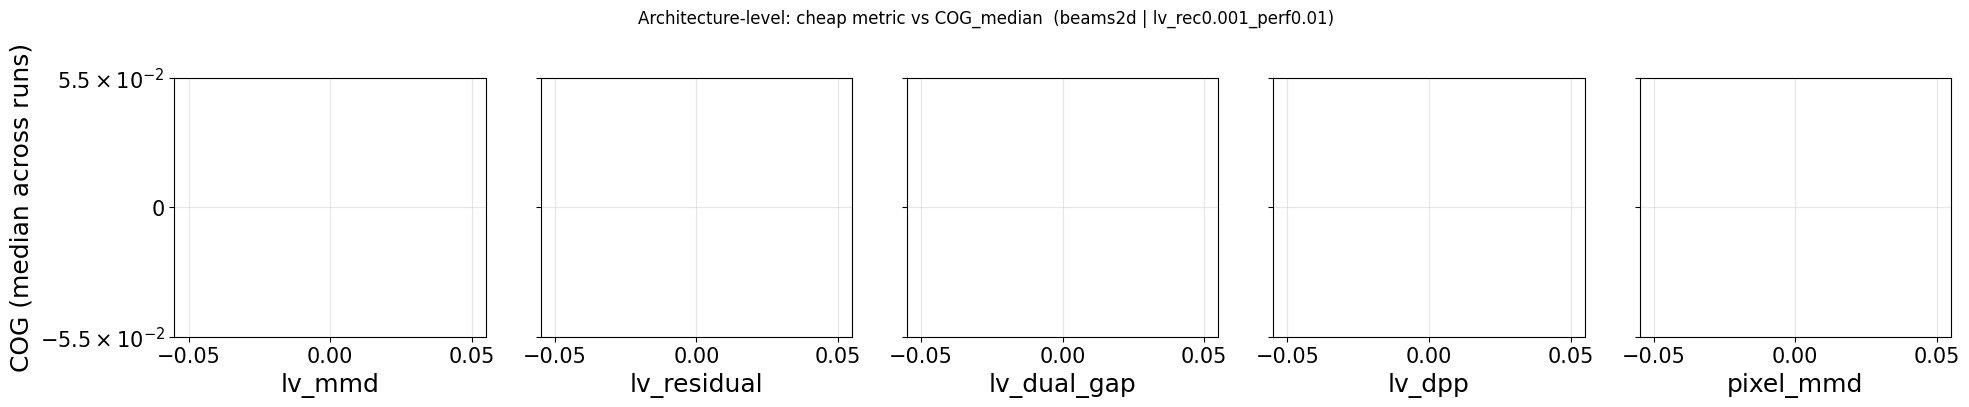


=== Architecture-level (median over seeds 1-10)  --  heatconduction2d  (lv_rec0.015_perf0.01_lvae1) ===
metric                   cgan_cnn_2d     diffusion_2d_cond            gan_cnn_2d                 vqgan
------------------------------------------------------------------------------------------------------
lv_mmd                        0.3017                0.4593                0.3212                0.0618
lv_residual                   0.1176                0.1334                0.0938                0.0587
lv_dual_gap                   0.0648                0.1319                0.0591                0.0336
lv_dpp                     -449.8989             -318.2355             -264.1012             -181.5376
pixel_mmd                     0.4647                0.6003                0.1753                0.0613
cog_median                       nan                   nan                   nan                   nan
iog_median                       nan                   nan             

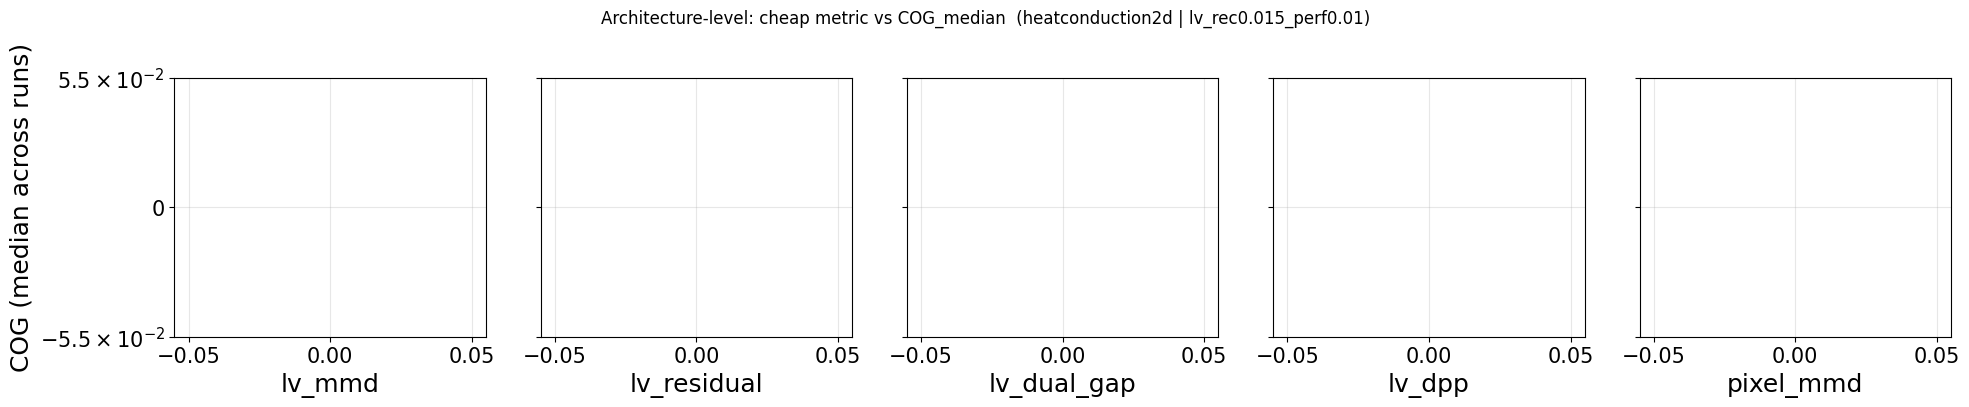

In [25]:
# --- Architecture-level rank tables + scatter, looping over problems ---------
# Per architecture, take the median cheap-metric and median COG_median across
# seeds 1-10, then plot one (cheap metric x COG_median) panel per architecture.
def _agg_by_arch(rows: list[dict], key: str, agg=np.nanmedian) -> dict[str, float]:
    out: dict[str, list[float]] = {}
    for r in rows:
        v = r.get(key)
        if v is None or not np.isfinite(float(v or np.nan)):
            continue
        out.setdefault(r["model_id"], []).append(float(v))
    return {m: float(agg(v)) for m, v in out.items() if v}


CHEAP_METRICS_SCATTER = ["lv_mmd", "lv_residual", "lv_dual_gap", "lv_dpp", "pixel_mmd"]

for prob, by_prefix in ranking_runs_by_problem.items():
    prefixes = lv_prefixes_by_problem[prob]
    if not prefixes:
        continue
    primary_prefix = prefixes[0]
    rows = by_prefix[primary_prefix]
    archs_here = sorted({r["model_id"] for r in rows})

    arch_summary = {k: _agg_by_arch(rows, k) for k in CHEAP_METRICS_SCATTER + ["cog_median", "iog_median"]}

    print(f"\n=== Architecture-level (median over seeds 1-{max(SEEDS_TO_ANALYSE)})  --  {prob}  ({primary_prefix}) ===")
    print(f"{'metric':14s}  " + "  ".join(f"{a:>20s}" for a in archs_here))
    print("-" * (14 + 22 * len(archs_here)))
    for k in CHEAP_METRICS_SCATTER + ["cog_median", "iog_median"]:
        cells = []
        for a in archs_here:
            v = arch_summary[k].get(a, np.nan)
            cells.append(f"{v:>20.4f}" if np.isfinite(v) else f"{'nan':>20s}")
        print(f"{k:14s}  " + "  ".join(cells))

    fig, axes = plt.subplots(1, len(CHEAP_METRICS_SCATTER), figsize=(4.0 * len(CHEAP_METRICS_SCATTER), 4.2), sharey=True)
    for ax, c in zip(axes, CHEAP_METRICS_SCATTER):
        xs, ys, names = [], [], []
        for a in archs_here:
            x, y = arch_summary[c].get(a), arch_summary["cog_median"].get(a)
            if x is None or y is None or not np.isfinite(x) or not np.isfinite(y):
                continue
            xs.append(x)
            ys.append(y)
            names.append(a)
        ax.scatter(xs, ys, s=140, c=[ARCH_COL.get(n, "0.6") for n in names], edgecolor="black", linewidth=0.8)
        for x, y, n in zip(xs, ys, names):
            ax.annotate(n, (x, y), xytext=(6, 6), textcoords="offset points", fontsize=9)
        ax.set_xlabel(c)
        ax.set_yscale("symlog")
        ax.grid(True, alpha=0.3)
    axes[0].set_ylabel("COG (median across runs)")
    fig.suptitle(
        f"Architecture-level: cheap metric vs COG_median  ({prob} | {primary_prefix.replace('_lvae1', '')})", fontsize=12
    )
    fig.tight_layout()
    save_vec(fig, f"architecture_rank_scatter_{prob}")
    plt.show()

## Validation&nbsp;B &mdash; On-manifold vs off-manifold detection / diversity

The abstract's projection-property claim says the encoder maps any input to
its on-manifold projection. This section visualises that claim and
quantifies it: we feed two classes of garbage (noise-shaped, physical-shaped)
through both LVAEs and check whether the projection residual (and PRDC
diversity metrics) flag them.

The garbage battery was already encoded in section&nbsp;1 (`enc_noise`,
`enc_phys`).


re-encode drift (active-dim L2):
  noise-shaped : median=6.292  max=9.624
  physical     : median=8.149   max=10.713
saved: ../../paper/figures/latent_scatter_diagnostic.{pdf,svg,png}


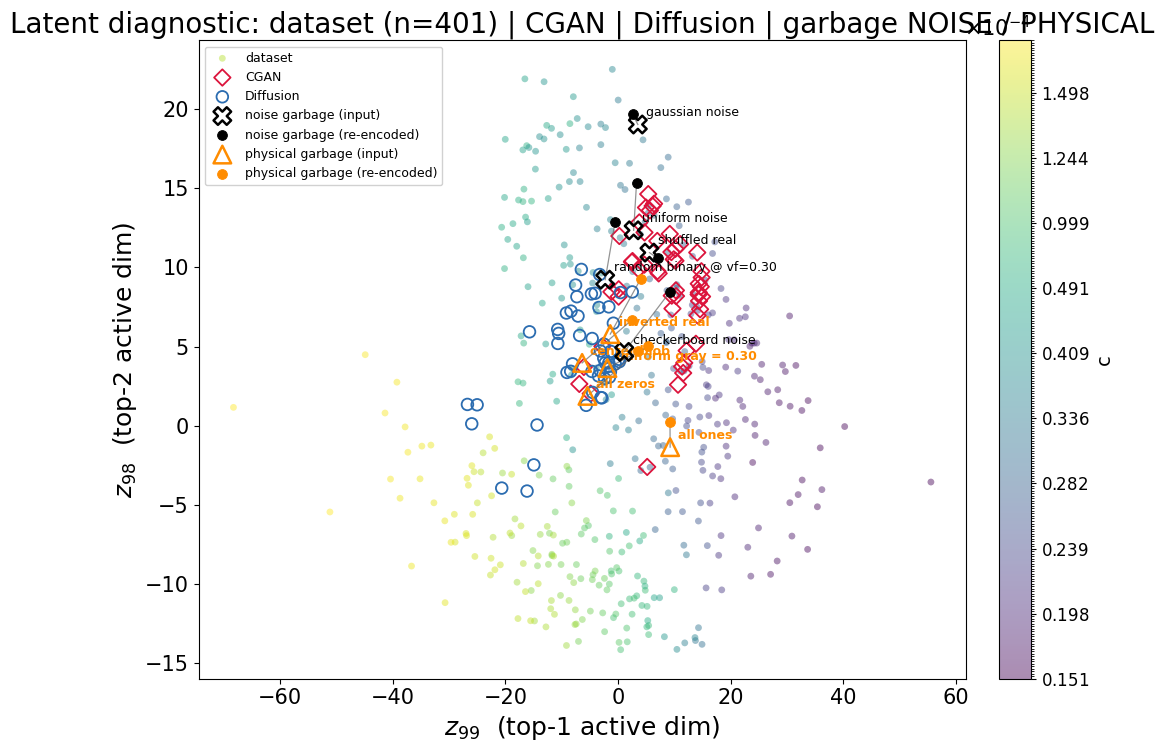

In [26]:
# --- Latent diagnostic scatter: dataset + CGAN + Diff + garbage classes ------
# One representative per garbage type, with re-encoded follow-up to check the
# encoder is approximately idempotent on its image.

n_noise = len(NOISE_TYPES)
n_phys = len(PHYS_TYPES)
z_noise_repr = enc_noise["z_perf"][:n_noise]
z_phys_repr = enc_phys["z_perf"][:n_phys]
proj_noise_repr = enc_noise["proj_perf"][:n_noise]
proj_phys_repr = enc_phys["proj_perf"][:n_phys]

with th.no_grad():
    z_noise_re = encoder_perf(th.from_numpy(proj_noise_repr).float().unsqueeze(1).to(device)).cpu().numpy()
    z_phys_re = encoder_perf(th.from_numpy(proj_phys_repr).float().unsqueeze(1).to(device)).cpu().numpy()

drift_n = np.linalg.norm(z_noise_repr[:, active_dims] - z_noise_re[:, active_dims], axis=1)
drift_p = np.linalg.norm(z_phys_repr[:, active_dims] - z_phys_re[:, active_dims], axis=1)
print("re-encode drift (active-dim L2):")
print(f"  noise-shaped : median={np.median(drift_n):.3f}  max={drift_n.max():.3f}")
print(f"  physical     : median={np.median(drift_p):.3f}   max={drift_p.max():.3f}")

fig, ax = plt.subplots(figsize=(10.5, 7.8))
sc = latent_scatter_dataset(ax)
ax.scatter(
    enc_cgan["z_perf"][:, d0],
    enc_cgan["z_perf"][:, d1],
    facecolors="none",
    edgecolors="crimson",
    s=70,
    lw=1.3,
    marker="D",
    label="CGAN",
    zorder=3,
)
ax.scatter(
    enc_diff["z_perf"][:, d0],
    enc_diff["z_perf"][:, d1],
    facecolors="none",
    edgecolors="#2b6cb0",
    s=70,
    lw=1.3,
    marker="o",
    label="Diffusion",
    zorder=3,
)

for src_z, src_z_re, names, colour, marker, label in [
    (z_noise_repr, z_noise_re, NOISE_TYPES, "black", "X", "noise garbage"),
    (z_phys_repr, z_phys_re, PHYS_TYPES, "darkorange", "^", "physical garbage"),
]:
    nx_, ny_ = src_z[:, d0], src_z[:, d1]
    rx_, ry_ = src_z_re[:, d0], src_z_re[:, d1]
    for a, b, c, d in zip(nx_, ny_, rx_, ry_):
        ax.plot([a, c], [b, d], color="0.4", lw=0.9, alpha=0.7, zorder=4)
    ax.scatter(
        nx_, ny_, facecolors="none", edgecolors=colour, s=160, lw=1.8, marker=marker, label=f"{label} (input)", zorder=5
    )
    ax.scatter(
        rx_, ry_, facecolors=colour, edgecolors=colour, s=50, lw=0.6, marker="o", label=f"{label} (re-encoded)", zorder=6
    )
    for i, n in enumerate(names):
        ax.annotate(
            n,
            (nx_[i], ny_[i]),
            xytext=(6, 6),
            textcoords="offset points",
            fontsize=9,
            color=colour,
            fontweight="bold" if colour == "darkorange" else "normal",
        )

colourbar(ax, sc)
ax.set_xlabel(f"$z_{{{d0}}}$  (top-1 active dim)")
ax.set_ylabel(f"$z_{{{d1}}}$  (top-2 active dim)")
ax.set_title(f"Latent diagnostic: dataset (n={len(z_dataset)}) | CGAN | Diffusion | garbage NOISE / PHYSICAL")
ax.legend(loc="best", fontsize=9, framealpha=0.9)
fig.tight_layout()
save_vec(fig, "latent_scatter_diagnostic")
plt.show()


PRDC in latent space (active dims = 9, k = 5, n = N_COMMON = 50)

set                        precision      recall     density    coverage
----------------------------------------------------------------------
self (train/2 vs ref)          0.980       1.000       0.916       1.000
test (real)                    0.880       0.600       0.852       0.720
CGAN                           1.000       0.060       1.556       0.460
Diffusion                      1.000       0.120       0.820       0.420
garbage: noise                 1.000       0.060       1.132       0.260
garbage: physical              1.000       0.000       0.856       0.240
saved: ../../paper/figures/prdc_panels.{pdf,svg,png}


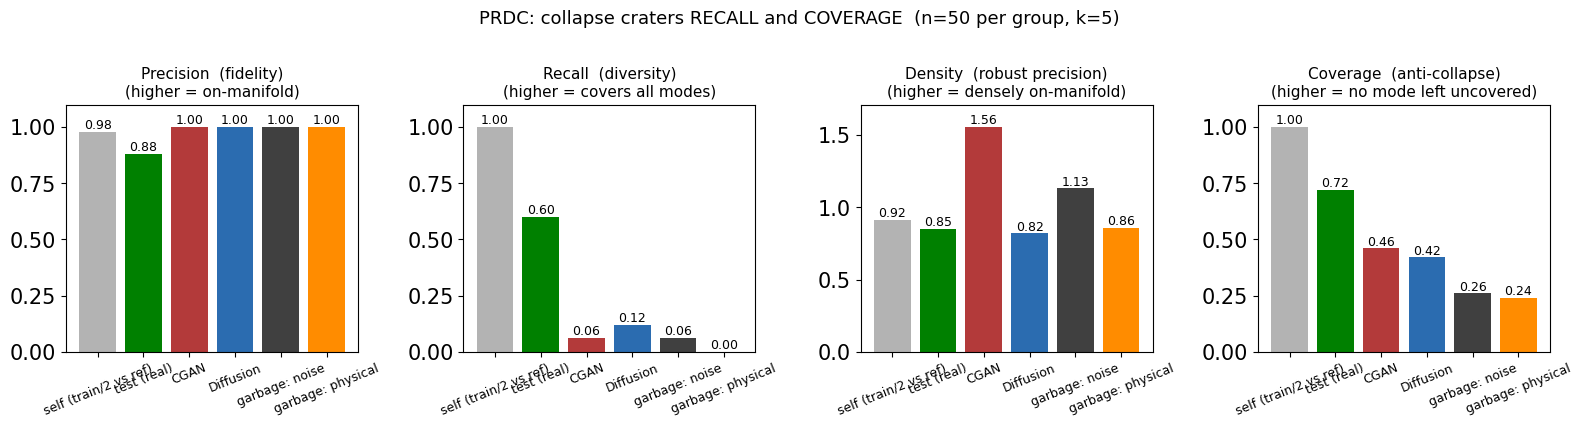

In [27]:
# --- PRDC: precision / recall / density / coverage in the latent space -------
# Kynkaanniemi 2019 (precision, recall) + Naeem 2020 (density, coverage).
# Pinpoints mode collapse (low recall + low coverage) that MMD can miss.

K_NN = 5


def _pairwise(a, b):
    return np.sqrt(np.maximum(((a[:, None, :] - b[None, :, :]) ** 2).sum(-1), 0.0))


def _kth_nn(x, k):
    d = _pairwise(x, x)
    np.fill_diagonal(d, np.inf)
    return np.sort(d, axis=1)[:, k - 1]


def prdc(real, fake, k=K_NN):
    rr = _kth_nn(real, k)
    fr = _kth_nn(fake, k)
    d = _pairwise(real, fake)
    return {
        "precision": float(np.mean((d <= rr[:, None]).any(axis=0))),
        "recall": float(np.mean((d <= fr[None, :]).any(axis=1))),
        "density": float((1.0 / k) * np.mean((d <= rr[:, None]).sum(axis=0))),
        "coverage": float(np.mean(d.min(axis=1) <= rr)),
    }


z_ref_eval = LAT_SETS["ref_eval"]
prdc_rows = [
    ("self (train/2 vs ref)", prdc(z_ref_eval, LAT_SETS["self_a"])),
    ("test (real)", prdc(z_ref_eval, LAT_SETS["test"])),
    ("CGAN", prdc(z_ref_eval, LAT_SETS["cgan"])),
    ("Diffusion", prdc(z_ref_eval, LAT_SETS["diff"])),
    ("garbage: noise", prdc(z_ref_eval, LAT_SETS["noise"])),
    ("garbage: physical", prdc(z_ref_eval, LAT_SETS["phys"])),
]
print(f"\nPRDC in latent space (active dims = {len(active_dims)}, k = {K_NN}, n = N_COMMON = {N_COMMON})\n")
print(f"{'set':24s}  {'precision':>10s}  {'recall':>10s}  {'density':>10s}  {'coverage':>10s}")
print("-" * 70)
for label, m in prdc_rows:
    print(f"{label:24s}  {m['precision']:10.3f}  {m['recall']:10.3f}  {m['density']:10.3f}  {m['coverage']:10.3f}")

fig, axes = plt.subplots(1, 4, figsize=(16.0, 4.4))
labels = [r[0] for r in prdc_rows]
colours = ["0.7", "green", "#b33a3a", "#2b6cb0", "0.25", "darkorange"]
for ax, key, title, hint in zip(
    axes,
    ("precision", "recall", "density", "coverage"),
    ("Precision  (fidelity)", "Recall  (diversity)", "Density  (robust precision)", "Coverage  (anti-collapse)"),
    (
        "higher = on-manifold",
        "higher = covers all modes",
        "higher = densely on-manifold",
        "higher = no mode left uncovered",
    ),
):
    vals = [m[key] for _, m in prdc_rows]
    ax.bar(labels, vals, color=colours)
    ax.set_title(f"{title}\n({hint})", fontsize=11)
    ax.set_ylim(0, max(1.05, max(vals) * 1.1))
    ax.tick_params(axis="x", rotation=22, labelsize=9)
    for i, v in enumerate(vals):
        ax.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=9)
fig.suptitle(f"PRDC: collapse craters RECALL and COVERAGE  (n={N_COMMON} per group, k={K_NN})", fontsize=13)
fig.tight_layout()
save_vec(fig, "prdc_panels")
plt.show()

saved: ../../paper/figures/joint_diagnostic.{pdf,svg,png}


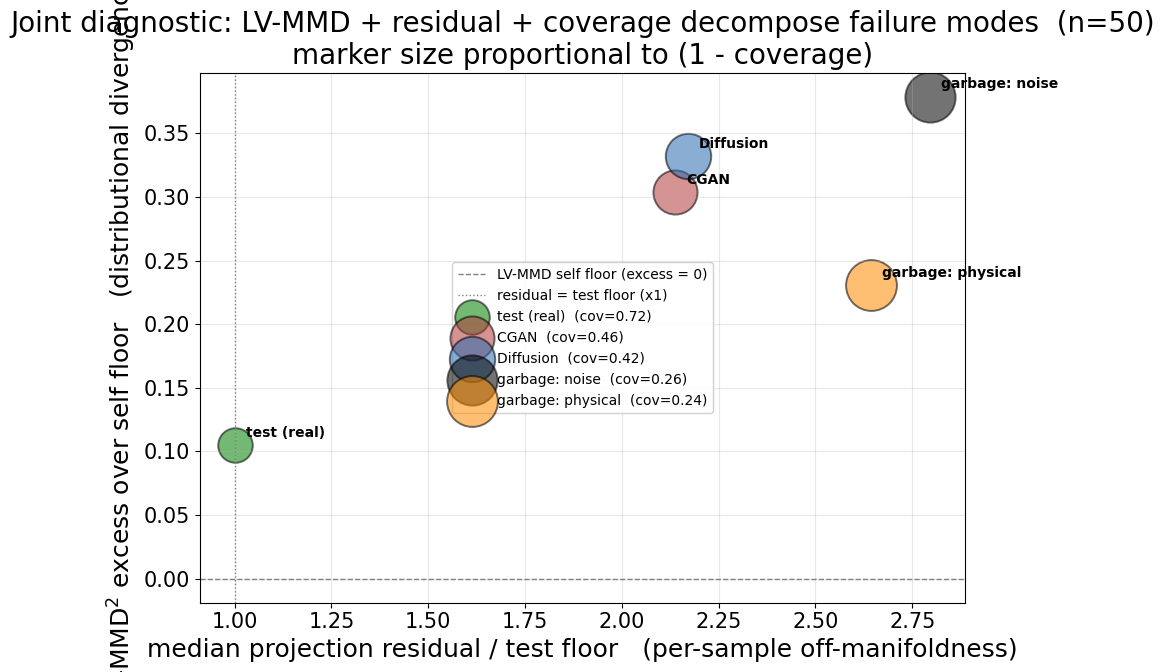


Joint diagnostic table  (n=50 per group):
set                        res / floor    LV-MMD2 excess    coverage
----------------------------------------------------------------------
test (real)                       1.00            0.1051        0.72
CGAN                              2.14            0.3038        0.46
Diffusion                         2.17            0.3323        0.42
garbage: noise                    2.80            0.3786        0.26
garbage: physical                 2.64            0.2306        0.24


In [28]:
# --- Joint diagnostic: LV-MMD excess + residual + coverage -------------------
# Each candidate set is one point on a 2D plane (residual x LV-MMD excess),
# with marker size encoding (1 - coverage).  One-glance failure-mode summary.

self_lv = mmd_table[0][2]
joint_data = {
    "test (real)": {
        "res": float(np.median(_take(enc_test["proj_res_l2"], N_COMMON, 10))),
        "lv": mmd_table[1][2] - self_lv,
        "cov": prdc_rows[1][1]["coverage"],
        "col": "green",
    },
    "CGAN": {
        "res": float(np.median(_take(enc_cgan["proj_res_l2"], N_COMMON, 11))),
        "lv": mmd_table[2][2] - self_lv,
        "cov": prdc_rows[2][1]["coverage"],
        "col": "#b33a3a",
    },
    "Diffusion": {
        "res": float(np.median(_take(enc_diff["proj_res_l2"], N_COMMON, 12))),
        "lv": mmd_table[3][2] - self_lv,
        "cov": prdc_rows[3][1]["coverage"],
        "col": "#2b6cb0",
    },
    "garbage: noise": {
        "res": float(np.median(_take(enc_noise["proj_res_l2"], N_COMMON, 13))),
        "lv": mmd_table[4][2] - self_lv,
        "cov": prdc_rows[4][1]["coverage"],
        "col": "black",
    },
    "garbage: physical": {
        "res": float(np.median(_take(enc_phys["proj_res_l2"], N_COMMON, 14))),
        "lv": mmd_table[5][2] - self_lv,
        "cov": prdc_rows[5][1]["coverage"],
        "col": "darkorange",
    },
}
floor_res = joint_data["test (real)"]["res"]

fig, ax = plt.subplots(figsize=(10.0, 7.0))
ax.axhline(0.0, color="0.5", ls="--", lw=1.0, label="LV-MMD self floor (excess = 0)")
ax.axvline(1.0, color="0.5", ls=":", lw=1.0, label="residual = test floor (x1)")

for label, d in joint_data.items():
    x = d["res"] / floor_res
    y = d["lv"]
    s = 200 + 1500 * (1.0 - d["cov"])
    ax.scatter(
        x, y, s=s, c=d["col"], alpha=0.55, edgecolors="black", linewidths=1.4, label=f"{label}  (cov={d['cov']:.2f})"
    )
    ax.annotate(label, (x, y), xytext=(8, 6), textcoords="offset points", fontsize=10, fontweight="bold")

ax.set_xlabel("median projection residual / test floor   (per-sample off-manifoldness)")
ax.set_ylabel("LV-MMD$^2$ excess over self floor   (distributional divergence)")
ax.set_title(
    f"Joint diagnostic: LV-MMD + residual + coverage decompose failure modes  (n={N_COMMON})\n"
    "marker size proportional to (1 - coverage)"
)
ax.legend(loc="best", fontsize=10, framealpha=0.9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
save_vec(fig, "joint_diagnostic")
plt.show()

print(f"\nJoint diagnostic table  (n={N_COMMON} per group):")
print(f"{'set':24s}  {'res / floor':>12s}  {'LV-MMD2 excess':>16s}  {'coverage':>10s}")
print("-" * 70)
for label, d in joint_data.items():
    print(f"{label:24s}  {d['res'] / floor_res:12.2f}  {d['lv']:16.4f}  {d['cov']:10.2f}")

## Visual summary &mdash; god-figure latent scatter

The single figure that ties everything together: dataset cloud (coloured by
compliance), test targets at the sampled conditions, CGAN samples (linked by
thin lines to their target), and the gold-starred `HIGHLIGHT_IDX`.


saved: ../../paper/figures/latent_scatter.{pdf,svg,png}


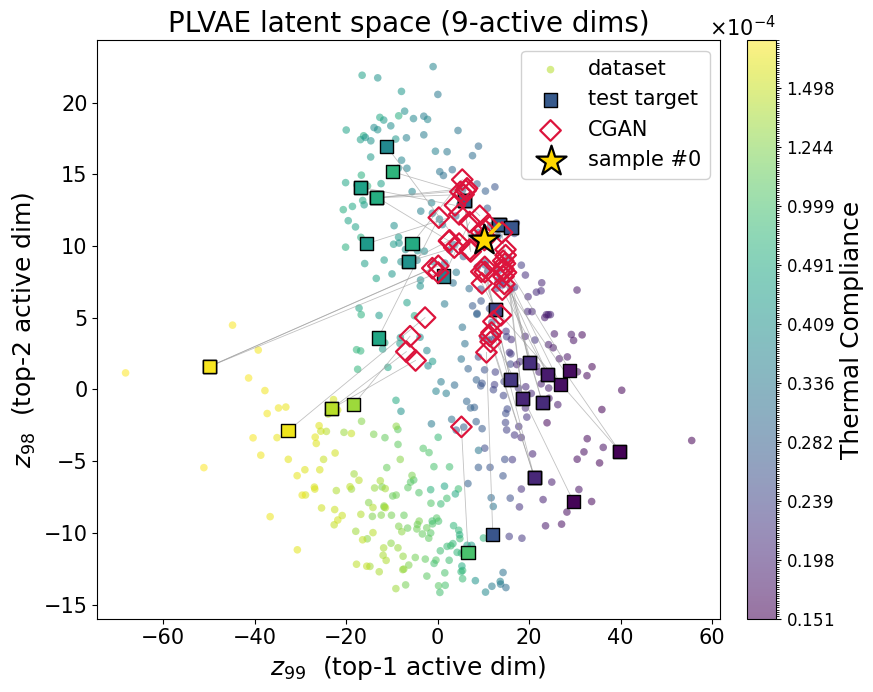

In [29]:
# --- God-figure latent scatter ------------------------------------------------
fig, ax = plt.subplots(figsize=(9.0, 7.2))
sc = latent_scatter_dataset(ax, s=30, alpha=0.55)

z_targets_active = enc_targets["z_perf"]
z_cgan_active = enc_cgan["z_perf"]

for i in range(N_GEN_SAMPLES):
    ax.plot(
        [z_targets_active[i, d0], z_cgan_active[i, d0]],
        [z_targets_active[i, d1], z_cgan_active[i, d1]],
        color="0.6",
        linewidth=0.6,
        alpha=0.6,
        zorder=1,
    )

ax.scatter(
    z_targets_active[:, d0],
    z_targets_active[:, d1],
    c=p_test_targets[:, 0],
    cmap="viridis",
    norm=P_NORM,
    s=90,
    marker="s",
    edgecolor="black",
    linewidth=1.0,
    label="test target",
    zorder=3,
)
ax.scatter(
    z_cgan_active[:, d0],
    z_cgan_active[:, d1],
    facecolors="none",
    edgecolors="crimson",
    s=110,
    linewidth=1.6,
    marker="D",
    label="CGAN",
    zorder=4,
)

ax.plot(
    [z_targets_active[HIGHLIGHT_IDX, d0], z_cgan_active[HIGHLIGHT_IDX, d0]],
    [z_targets_active[HIGHLIGHT_IDX, d1], z_cgan_active[HIGHLIGHT_IDX, d1]],
    color="gold",
    linewidth=2.6,
    alpha=0.95,
    zorder=5,
)
ax.scatter(
    z_cgan_active[HIGHLIGHT_IDX, d0],
    z_cgan_active[HIGHLIGHT_IDX, d1],
    marker="*",
    s=520,
    facecolor="gold",
    edgecolor="black",
    linewidth=1.6,
    zorder=6,
    label=f"sample #{HIGHLIGHT_IDX}",
)

ax.set_xlabel(f"$z_{{{d0}}}$  (top-1 active dim)")
ax.set_ylabel(f"$z_{{{d1}}}$  (top-2 active dim)")
colourbar(ax, sc).set_label("Thermal Compliance", fontsize=18)
ax.legend(loc="best", frameon=True, framealpha=0.9)
ax.set_title(f"PLVAE latent space ({len(active_dims)}-active dims)")
fig.tight_layout()
save_vec(fig, "latent_scatter")
plt.show()